In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
# import mne
import tqdm
from typing import Literal

In [3]:
# Parametri del filtro
lowcut = 0.5
highcut = 60.0
fs = 200.0  # Frequenza di campionamento (in Hz)

In [4]:
dataset_dir = "../dataset"
old_dataset_dir = "../dataset_old"
eeg_windows_dir = os.path.join(dataset_dir, "eeg_windows")
filtered_eeg_windows_dir = os.path.join(dataset_dir, f"filtered_eeg_windows_{int(highcut)}Hz")
dataset_df = pd.read_csv(os.path.join(dataset_dir, "dataset.csv"))

# Data visualization

In [4]:
dataset_df.head()

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


In [5]:
dataset_df.describe()

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
count,1.068000e+05,106800.000000,106800.000000,1.068000e+05,106800.000000,106800.000000,1.068000e+05,106800.000000,106800.000000,106800.000000,106800.000000,106800.000000,106800.000000,106800.000000
mean,2.104387e+09,26.286189,118.817228,1.067262e+09,43.733596,520.431404,2.141415e+09,32304.428493,0.878024,1.138783,1.264925,0.948296,1.059185,1.966283
std,1.233371e+09,69.757658,314.557803,6.291475e+08,104.292116,1449.759868,1.241670e+09,18538.196252,1.538873,2.818845,3.131889,2.136799,2.228492,3.621180
min,5.686570e+05,0.000000,0.000000,3.537330e+05,0.000000,0.000000,3.380000e+02,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.026896e+09,1.000000,6.000000,5.238626e+08,2.000000,12.000000,1.067419e+09,16707.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.071326e+09,5.000000,26.000000,1.057904e+09,8.000000,62.000000,2.138332e+09,32068.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.172787e+09,16.000000,82.000000,1.623195e+09,29.000000,394.000000,3.217816e+09,48036.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000
max,4.294958e+09,742.000000,3372.000000,2.147388e+09,1021.000000,17632.000000,4.294934e+09,65494.000000,19.000000,18.000000,16.000000,15.000000,15.000000,25.000000


expert_consensus
Seizure    0.196002
GRDA       0.176601
Other      0.176105
GPD        0.156386
LRDA       0.155805
LPD        0.139101
Name: proportion, dtype: float64


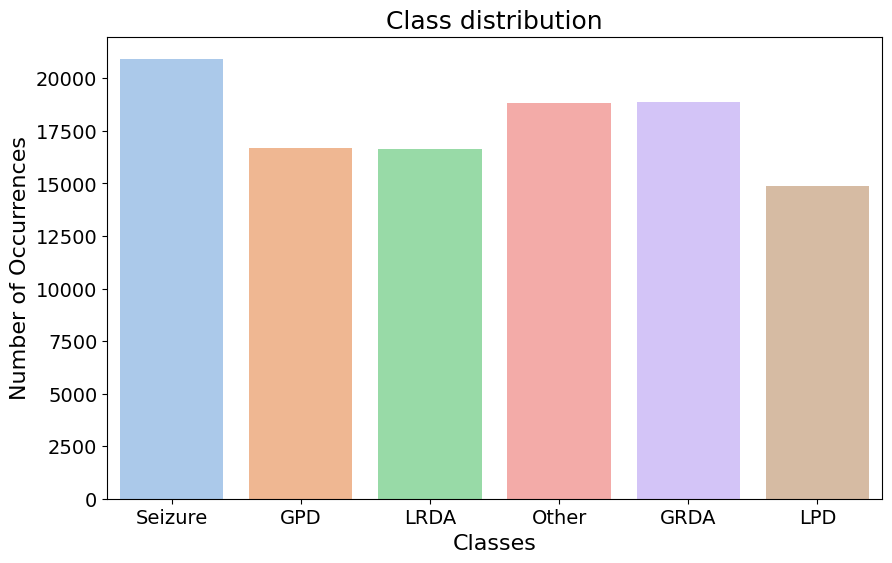

In [5]:
# Stampa delle proporzioni di ogni classe
print(dataset_df["expert_consensus"].value_counts(normalize=True))

def plot_class_distribution(dataset_df: pd.DataFrame, palette: Literal["pastel", "deep", "muted", "bright", "colorblind"] = "pastel") -> None:
    # Creazione del grafico a barre con palette predefinita "pastel"
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x="expert_consensus", hue="expert_consensus", data=dataset_df, palette=palette, legend=False)

    # Titolo e labels
    plt.title('Class distribution', fontsize=18)
    plt.xlabel('Classes', fontsize=16)
    plt.ylabel('Number of Occurrences', fontsize=16)

    # Aumenta il font dei tick
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Visualizzazione del grafico
    plt.show()

plot_class_distribution(dataset_df)

# Data cleaning

### Remove NaN values

In [7]:
# for every row of dataset_df we load the corresponding EEG window and check if it contains NaN values

eeg_files_with_nans = []

def check_nan_values(dataset_df: pd.DataFrame) -> None:
    for index, row in dataset_df.iterrows():
        filename = row["label_id"]
        eeg_window = pd.read_csv(f"{eeg_windows_dir}/{filename}.csv")
        if eeg_window.isnull().values.any():
            #print(f"NaN values found in {filename}")
            eeg_files_with_nans.append(filename)

check_nan_values(dataset_df)

print(f"Number of EEG files with NaN values: {len(eeg_files_with_nans)}")
#save the list of EEG files with NaN values as a csv file
pd.DataFrame(eeg_files_with_nans).to_csv(f"{dataset_dir}/eeg_files_with_nans.csv", index=False, header=False)

Number of EEG files with NaN values: 727


Number of rows in the dataset after removing NaN values: 106073
expert_consensus
Seizure    0.196751
GRDA       0.176548
Other      0.175888
GPD        0.156703
LRDA       0.155299
LPD        0.138810
Name: proportion, dtype: float64
expert_consensus
Seizure    20870
GRDA       18727
Other      18657
GPD        16622
LRDA       16473
LPD        14724
Name: count, dtype: int64


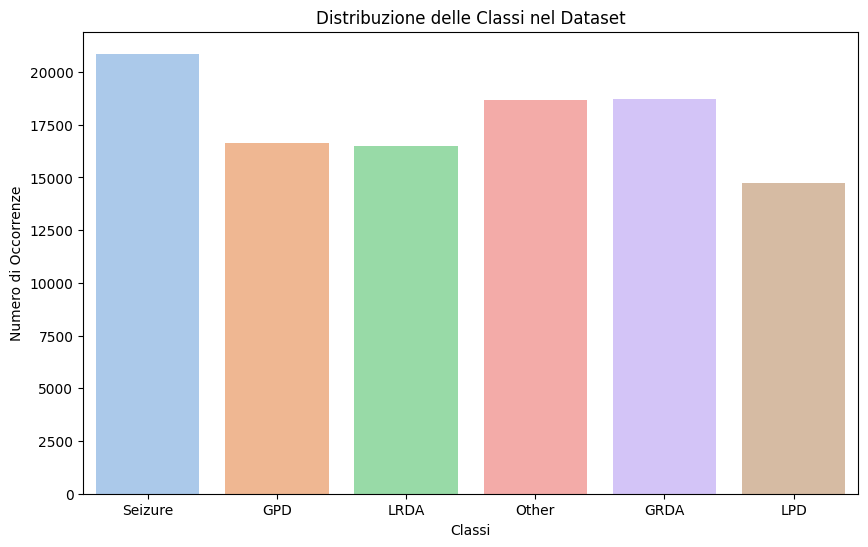

In [ ]:
eeg_files_with_nans = pd.read_csv(f"{dataset_dir}/eeg_files_with_nans.csv", header=None).values.flatten()

#remove rows with NaN values
dataset_df = dataset_df[~dataset_df["label_id"].isin(eeg_files_with_nans)]
dataset_df.reset_index(drop=True, inplace=True)
print(f"Number of rows in the dataset after removing NaN values: {dataset_df.shape[0]}")

# Stampa delle proporzioni di ogni classe 
print(dataset_df["expert_consensus"].value_counts(normalize=True))
print(dataset_df["expert_consensus"].value_counts())

plot_class_distribution(dataset_df)

### Noise filtering

Index: 26299


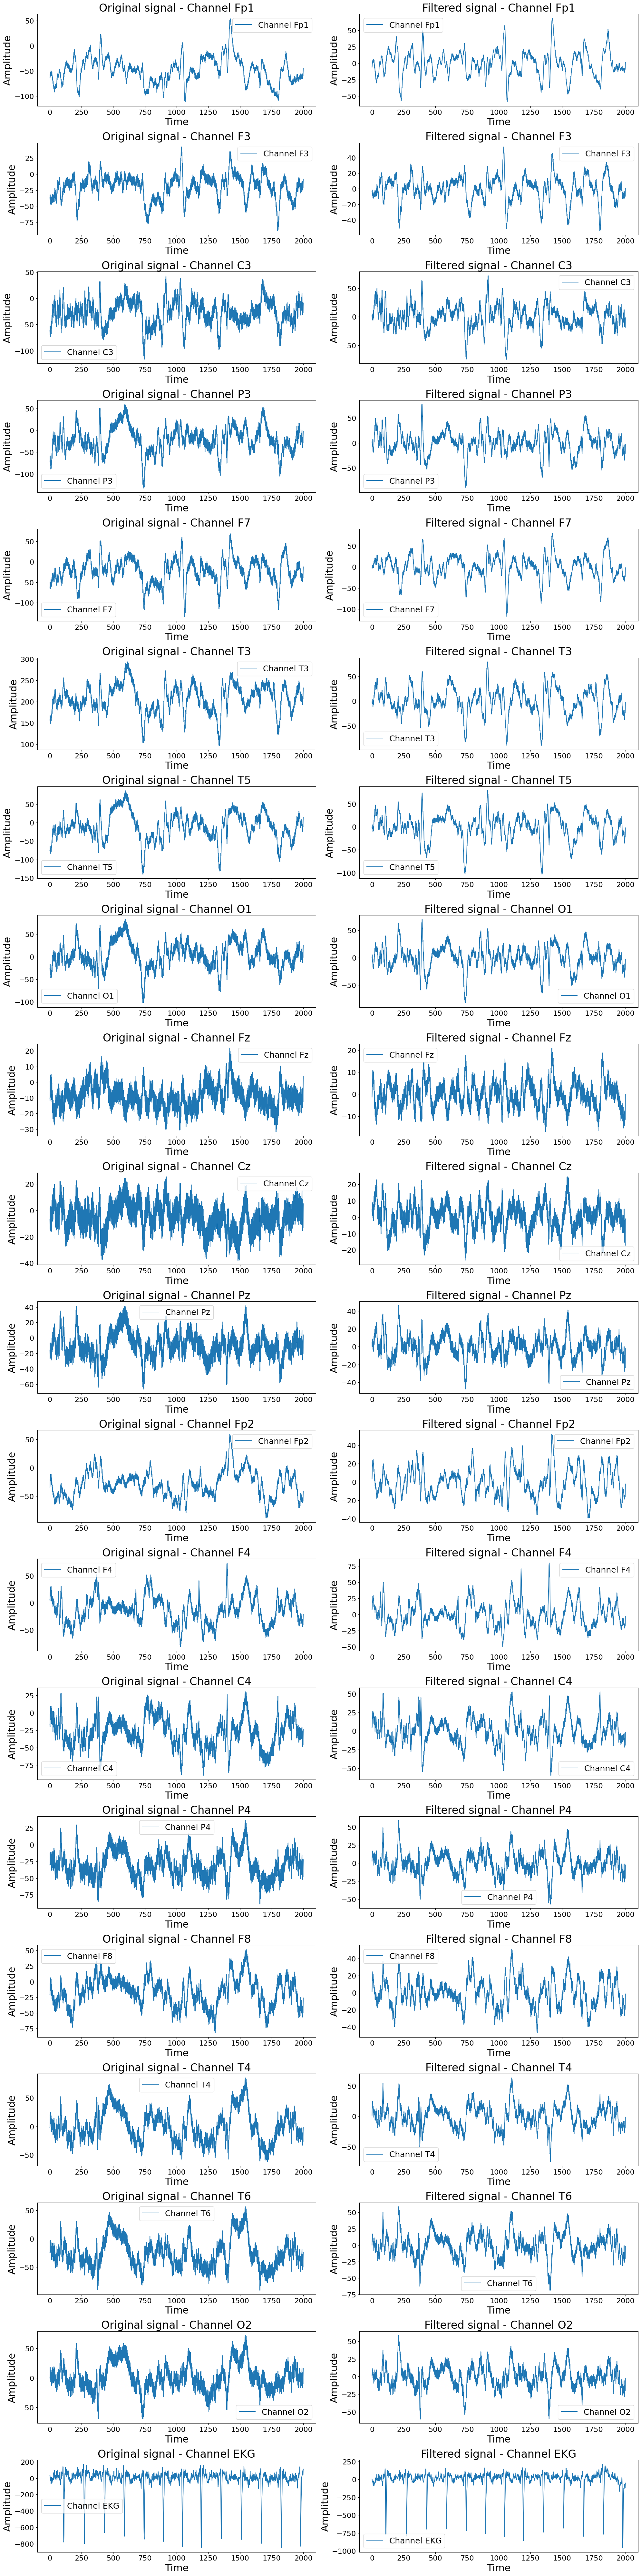

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


# Funzione per creare il filtro passabanda
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Funzione per applicare il filtro passabanda
def apply_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y


def plot_signals(before, after, n_channels=20, columns=None):
    fig, axes = plt.subplots(n_channels, 2, figsize=(20, 4 * n_channels))
    time = np.arange(before.shape[0])
    
    for i in range(n_channels):
        axes[i, 0].plot(time, before[:, i], label=f'Channel {columns[i] if columns is not None else i+1}')
        axes[i, 0].set_title(f'Original signal - Channel {columns[i] if columns is not None else i+1}', fontsize=24)
        axes[i, 0].set_xlabel('Time', fontsize=22)
        axes[i, 0].set_ylabel('Amplitude', fontsize=22)
        axes[i, 0].legend(fontsize=18)
        axes[i, 0].tick_params(axis='both', which='major', labelsize=16)
        
        axes[i, 1].plot(time, after[:, i], label=f'Channel {columns[i] if columns is not None else i+1}')
        axes[i, 1].set_title(f'Filtered signal - Channel {columns[i] if columns is not None else i+1}', fontsize=24)
        axes[i, 1].set_xlabel('Time', fontsize=22)
        axes[i, 1].set_ylabel('Amplitude', fontsize=22)
        axes[i, 1].legend(fontsize=18)
        axes[i, 1].tick_params(axis='both', which='major', labelsize=16)
    
    plt.tight_layout()
    plt.show()

# Parametri del filtro
lowcut = 0.5
highcut = 60.0
fs = 200.0  # Frequenza di campionamento (in Hz)


# Load the first EEG window and apply the bandpass filter
# row = dataset_df.iloc[50]
# genera un indice randomico
index = np.random.randint(0, dataset_df.shape[0])
print("Index:", index)
row = dataset_df.iloc[103463]
file_path = f'{eeg_windows_dir}/{row.label_id}.csv'
columns = pd.read_csv(file_path).columns
data = pd.read_csv(file_path).values

filtered_data = apply_bandpass_filter(data, lowcut, highcut, fs, order=5)

plot_signals(data, filtered_data, n_channels=data.shape[1], columns=columns)

In [ ]:
#filter entire dataset and save files in a new directory
filtered_eeg_windows_dir = os.path.join(dataset_dir, f'filtered_eeg_windows_{int(highcut)}Hz')
if not os.path.exists(filtered_eeg_windows_dir):
    os.makedirs(filtered_eeg_windows_dir)

def filter_dataset(dataset_df: pd.DataFrame, lowcut: float, highcut: float, fs: float, order: int) -> None:
    for index, row in dataset_df.iterrows():
        filename = row["label_id"]
        eeg_window = pd.read_csv(f"{eeg_windows_dir}/{filename}.csv")
        filtered_eeg_window = apply_bandpass_filter(eeg_window.values, lowcut, highcut, fs, order)
        pd.DataFrame(filtered_eeg_window).to_csv(f"{filtered_eeg_windows_dir}/{filename}.csv", index=False)

filter_dataset(dataset_df, lowcut, highcut, fs, 5)

#save the filtered dataset with header
dataset_df.to_csv(f"{dataset_dir}/filtered_{int(highcut)}Hz.csv", index=False)

# Data splitting

In [31]:
from sklearn.model_selection import train_test_split

#split dataset.csv in train, validation and test set maintaing the percentage of each class
def split_dataset(dataset_df: pd.DataFrame, train_size: float, validation_size: float, test_size: float, random_seed: int = 42):
    assert train_size + validation_size + test_size == 1.0, "train_size + validation_size + test_size must be equal to 1.0"
    assert train_size > 0 and validation_size > 0 and test_size > 0, "train_size, validation_size and test_size must be greater than 0"
    assert dataset_df["expert_consensus"].nunique() == 6, "The dataset must have only 6 classes"
    
    train_df = pd.DataFrame()
    validation_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    for class_label in dataset_df["expert_consensus"].unique():
        class_df = dataset_df[dataset_df["expert_consensus"] == class_label]
        
        train_df_class, validation_test_df_class = train_test_split(class_df, test_size=validation_size + test_size, random_state=random_seed, stratify=class_df["expert_consensus"])
        validation_df_class, test_df_class = train_test_split(validation_test_df_class, test_size=test_size / (validation_size + test_size), random_state=random_seed, stratify=validation_test_df_class["expert_consensus"])

        train_df = pd.concat([train_df, train_df_class])
        validation_df = pd.concat([validation_df, validation_df_class])
        test_df = pd.concat([test_df, test_df_class])

    return train_df, validation_df, test_df

Original dataset: 106073 samples
Train set: 74248 samples
Validation set: 15911 samples
Test set: 15914 samples

--------------------------------------------------

Train set
expert_consensus
Seizure    0.196760
GRDA       0.176543
Other      0.175884
GPD        0.156705
LRDA       0.155304
LPD        0.138805
Name: proportion, dtype: float64


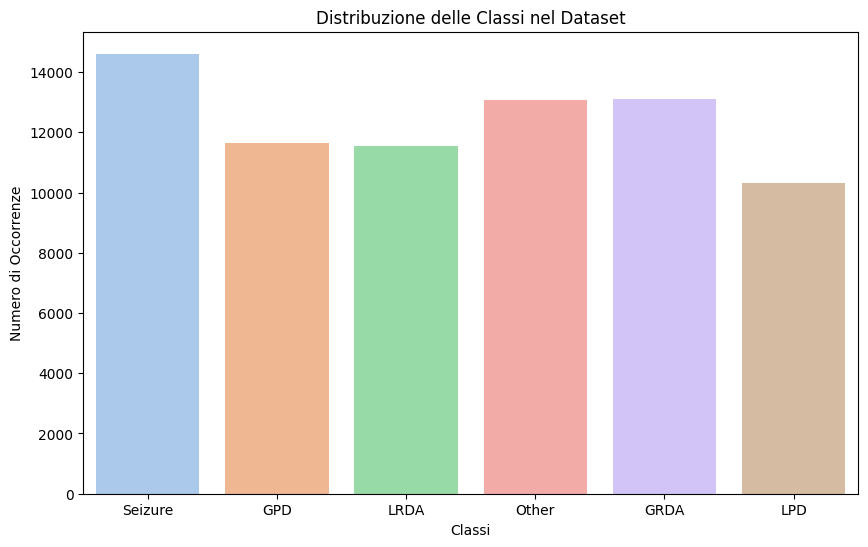

Validation set
expert_consensus
Seizure    0.196719
GRDA       0.176545
Other      0.175916
GPD        0.156684
LRDA       0.155301
LPD        0.138835
Name: proportion, dtype: float64


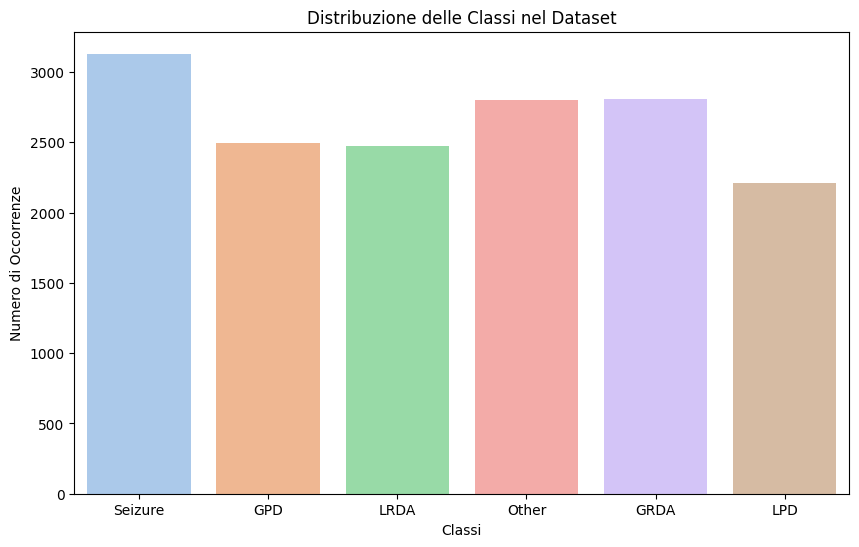

Test set
expert_consensus
Seizure    0.196745
GRDA       0.176574
Other      0.175883
GPD        0.156717
LRDA       0.155272
LPD        0.138809
Name: proportion, dtype: float64


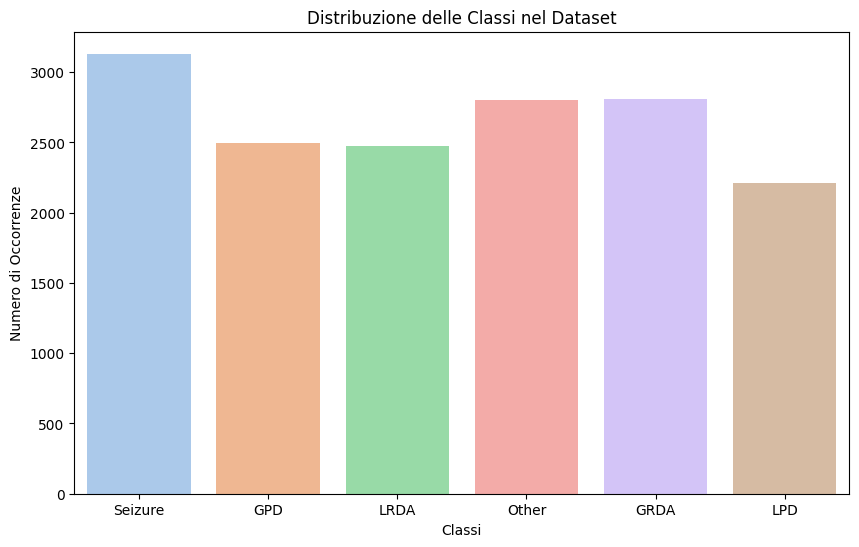

In [ ]:
train_df, validation_df, test_df = split_dataset(dataset_df, train_size=0.7, validation_size=0.15, test_size=0.15)

print(f"Original dataset: {dataset_df.shape[0]} samples")
print(f"Train set: {train_df.shape[0]} samples")
print(f"Validation set: {validation_df.shape[0]} samples")
print(f"Test set: {test_df.shape[0]} samples")

print("\n" + "-"*50 + "\n")

# Stampa delle proporzioni di ogni classe
print("Train set")
print(train_df["expert_consensus"].value_counts(normalize=True))
plot_class_distribution(train_df)

print("Validation set")
print(validation_df["expert_consensus"].value_counts(normalize=True))
plot_class_distribution(validation_df)

print("Test set")
print(test_df["expert_consensus"].value_counts(normalize=True))
plot_class_distribution(test_df)

train_df.to_csv(os.path.join(dataset_dir, "train_eegs.csv"), index=False)
validation_df.to_csv(os.path.join(dataset_dir, "val_eegs.csv"), index=False)
test_df.to_csv(os.path.join(dataset_dir, "test_eegs.csv"), index=False)

# EEG analysis

### Original EEG

In [ ]:
df_eeg = pd.read_parquet(os.path.join(dataset_dir, "eegs", "568657.parquet"))
df_eeg.head(10)

,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-75.360001,86.379997,65.470001,62.580002,170.350006,92.370003,39.680000,89.870003,18.260000,-28.440001,-15.190000,16.930000,13.810000,-42.160000,78.099998,-143.649994,121.239998,-1.470000,72.550003,-3090.090088
1,-107.739998,53.139999,32.590000,21.950001,140.500000,59.070000,4.260000,53.310001,-18.490000,-63.270000,-52.110001,-13.230000,-16.420000,-80.430000,64.449997,-168.500000,88.400002,-28.520000,40.250000,5560.439941
2,-103.050003,46.330002,10.750000,9.150000,137.820007,50.950001,-3.500000,45.070000,-20.879999,-66.629997,-69.750000,-9.200000,-21.400000,-93.089996,5.120000,-176.089996,51.689999,-38.639999,31.820000,-4161.450195
3,-75.099998,77.870003,40.150002,31.790001,166.630005,76.769997,17.990000,67.650002,11.140000,-32.950001,-38.509998,14.770000,9.790000,-66.480003,48.220001,-147.990005,86.629997,-18.639999,62.509998,31769.970703
4,-97.919998,58.209999,27.330000,5.340000,144.080002,47.200001,-10.430000,40.250000,-12.350000,-52.500000,-54.919998,-10.070000,-8.040000,-90.820000,67.269997,-164.710007,80.680000,-36.520000,41.830002,6879.720215
5,-114.940002,25.730000,-8.840000,-27.480000,117.059998,12.230000,-40.720001,11.000000,-40.009998,-76.620003,-87.290001,-29.120001,-42.639999,-120.910004,-4.880000,-199.059998,27.070000,-58.279999,13.130000,-795.150024
6,-95.639999,41.570000,8.560000,-8.910000,134.149994,30.090000,-21.639999,30.950001,-15.360000,-44.689999,-60.630001,-9.960000,-30.709999,-94.190002,1.510000,-185.199997,41.610001,-42.680000,39.320000,-1220.849976
7,-117.809998,35.849998,15.420000,-25.180000,118.269997,11.800000,-42.790001,9.710000,-19.049999,-44.689999,-58.790001,-32.090000,-38.450001,-94.010002,51.400002,-193.570007,55.220001,-52.459999,33.130001,-838.059998
8,-160.220001,-7.890000,-28.629999,-86.059998,66.919998,-46.180000,-104.239998,-53.549999,-57.840000,-82.879997,-111.820000,-75.019997,-77.930000,-138.759995,-10.800000,-240.350006,-4.200000,-93.070000,-20.820000,4253.379883
9,-138.509995,1.860000,-25.830000,-84.779999,78.790001,-39.009998,-100.690002,-52.000000,-38.669998,-62.150002,-105.849998,-57.750000,-65.699997,-125.919998,-44.180000,-235.259995,-18.719999,-94.180000,-17.760000,-2912.659912


In [ ]:
# campiona train.csv per ottenere un dataframe con un numero di campioni per classe uguale
def sample_train_dataset(train_df: pd.DataFrame, n_samples_per_class: int, random_seed: int = 42):
    assert n_samples_per_class > 0, "n_samples_per_class must be greater than 0"
    
    sampled_train_df = pd.DataFrame()
    
    for class_label in train_df["expert_consensus"].unique():
        class_df = train_df[train_df["expert_consensus"] == class_label]
        
        sampled_class_df = class_df.sample(n=n_samples_per_class, random_state=random_seed, replace=False)
        
        sampled_train_df = pd.concat([sampled_train_df, sampled_class_df])
    
    return sampled_train_df


In [ ]:
sampled_train_df = sample_train_dataset(train_df, n_samples_per_class=1000)
sampled_train_df.head()

In [ ]:
#salva sampled_train_df in un file csv
sampled_train_df.to_csv(os.path.join(dataset_dir, "sampled_train_eegs.csv"), index=False)

In [26]:
#leggere il dataset di train
train_df = pd.read_csv(os.path.join(dataset_dir, "train_eegs.csv"))
# per ogni classe stampa il totale di campioni
print(train_df["expert_consensus"].value_counts())
# calcola un vettore con il numero di campioni da prelevare per ogni classe (10% per classe)
n_samples_per_class = (train_df["expert_consensus"].value_counts() * 0.1).astype(int)
# stampa il vettore
print(n_samples_per_class)

# campiona il dataset di train per avere un numero di campioni per classe uguale a n_samples_per_class
def prop_sample_train_dataset(train_df: pd.DataFrame, n_samples_per_class: pd.Series, random_seed: int = 42):
    sampled_train_df = pd.DataFrame()
    
    for class_label in train_df["expert_consensus"].unique():
        class_df = train_df[train_df["expert_consensus"] == class_label]
        
        sampled_class_df = class_df.sample(n=n_samples_per_class[class_label], random_state=random_seed, replace=False)

        sampled_train_df = pd.concat([sampled_train_df, sampled_class_df])

    return sampled_train_df

expert_consensus
Seizure    14609
GRDA       13108
Other      13059
GPD        11635
LRDA       11531
LPD        10306
Name: count, dtype: int64
expert_consensus
Seizure    1460
GRDA       1310
Other      1305
GPD        1163
LRDA       1153
LPD        1030
Name: count, dtype: int32


In [27]:
sampled_train_df = prop_sample_train_dataset(train_df, n_samples_per_class)
# per ogni classe stampa il totale di campioni
print(sampled_train_df["expert_consensus"].value_counts())

sampled_train_df.to_csv(os.path.join(dataset_dir, "sampled10_train_eegs.csv"), index=False)

expert_consensus
Seizure    1460
GRDA       1310
Other      1305
GPD        1163
LRDA       1153
LPD        1030
Name: count, dtype: int64


In [6]:
# componi un dataframe con la concatenazione di tutti i csv di sampled_train_df
def create_eeg_windows_df(sampled_train_df: pd.DataFrame, eeg_windows_dir: str) -> pd.DataFrame:
    eeg_windows_df = pd.DataFrame()
    
    for index, row in sampled_train_df.iterrows():
        eeg_windows_file = os.path.join(eeg_windows_dir, f"{row['label_id']}.csv")
        df_eeg = pd.read_csv(eeg_windows_file)
        
        eeg_windows_df = pd.concat([eeg_windows_df, df_eeg])
    
    return eeg_windows_df

In [13]:
#leggi sampled_train_df da file csv
sampled_train_df = pd.read_csv(os.path.join(dataset_dir, "sampled_train_eegs.csv"))
eeg_windows_df = create_eeg_windows_df(sampled_train_df, eeg_windows_dir)
eeg_windows_df.head()

,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-25.25,-8.24,-22.33,-55.56,-10.10,225.43,-51.57,-27.91,-1.06,3.19,-11.43,-17.28,17.55,-14.09,-32.70,-9.57,-4.79,-35.09,-2.66,60.08
1,-25.25,-9.84,-30.57,-67.26,-17.01,214.53,-66.99,-37.22,-6.91,-6.11,-22.33,-19.41,15.42,-23.13,-48.65,-18.34,-18.87,-44.13,-10.90,27.64
2,-12.76,2.66,-26.85,-57.16,-5.85,224.10,-56.09,-39.34,-8.24,-10.90,-39.34,-16.48,17.01,-19.14,-30.84,-10.90,1.60,-39.88,-18.08,72.04
3,-18.61,3.72,-19.67,-52.64,-3.46,227.29,-59.28,-34.56,0.27,-1.06,-18.61,-20.47,18.08,-23.66,-38.01,-10.63,1.60,-37.48,-9.30,73.64
4,-22.33,-2.66,-25.52,-58.48,-14.89,210.54,-64.86,-30.31,-1.06,-3.19,-13.82,-22.86,22.86,-30.57,-49.98,-13.82,-1.33,-29.24,-2.66,22.33


In [14]:
#save eeg_windows_df.mean() and eeg_windows_df.std() in a csv file
eeg_windows_df_mean = eeg_windows_df.mean()
eeg_windows_df_std = eeg_windows_df.std()

stats_df = pd.DataFrame({
    'Mean': eeg_windows_df_mean,
    'Std': eeg_windows_df_std
})

print("DataFrame con media e deviazione standard:\n", stats_df)

output_file_path = os.path.join(dataset_dir, "eeg_windows_stats.csv")
stats_df = stats_df.round(2)
stats_df.to_csv(output_file_path, index_label='Channel', header=True)

print(f"File salvato in: {output_file_path}")

DataFrame con media e deviazione standard:
             Mean           Std
Fp1     9.091714    949.404870
F3     -7.847611    739.636262
C3     -4.658662    728.661385
P3     -3.843770    780.718799
F7      0.287427    801.035654
T3     -3.313439    707.668253
T5      3.113723    805.577277
O1      9.020637    912.689292
Fz     -2.252370    673.275402
Cz     -1.330128    695.283187
Pz     -5.808390    746.468901
Fp2     2.005582    754.319659
F4     -3.211135    756.084587
C4     -0.544219    813.022118
P4      4.375099    885.046665
F8     -2.955095    743.077405
T4     -1.049621    772.596508
T6     -3.606454    780.560939
O2     -4.673513    846.894320
EKG  1398.478476  40034.070651
File salvato in: ../dataset\eeg_windows_stats.csv


In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import norm
import numpy as np

def plot_eeg_histograms_with_gaussian(eeg_windows_df: pd.DataFrame, save_path) -> None:
    num_channels = len(eeg_windows_df.columns)
    cols = 2
    rows = (num_channels + cols - 1) // cols 
    
    # Creazione della figura e degli assi
    fig, axs = plt.subplots(rows, cols, figsize=(20, rows * 5))
    fig.suptitle('EEG Windows Histograms with Gaussian Fit')
    
    # Aggiustamento per rendere axs un array 1D per iterazione facile
    axs = axs.flatten()
    
    for i, channel in enumerate(eeg_windows_df.columns):

        sns.histplot(eeg_windows_df[channel], ax=axs[i], kde=False, stat="density", bins=100, color='lightblue')
        
        mean = eeg_windows_df[channel].mean()
        std = eeg_windows_df[channel].std()
        
        # Crea una sequenza di valori x per la gaussiana
        x = np.linspace(eeg_windows_df[channel].min(), eeg_windows_df[channel].max(), 100)
        
        # Calcola la distribuzione normale con la media e la deviaziaone standard calcolate
        y = norm.pdf(x, mean, std)
        
        # Plot della gaussiana
        axs[i].plot(x, y, color='red')
        axs[i].set_title(f"{channel} Histogram with Gaussian Fit", fontsize=22)
        axs[i].set_xlabel('Value', fontsize=20)
        axs[i].set_ylabel('Density', fontsize=20)
        axs[i].tick_params(axis='both', which='major', labelsize=16)
    
    # Rimozione di assi vuoti
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(save_path)
    plt.show()


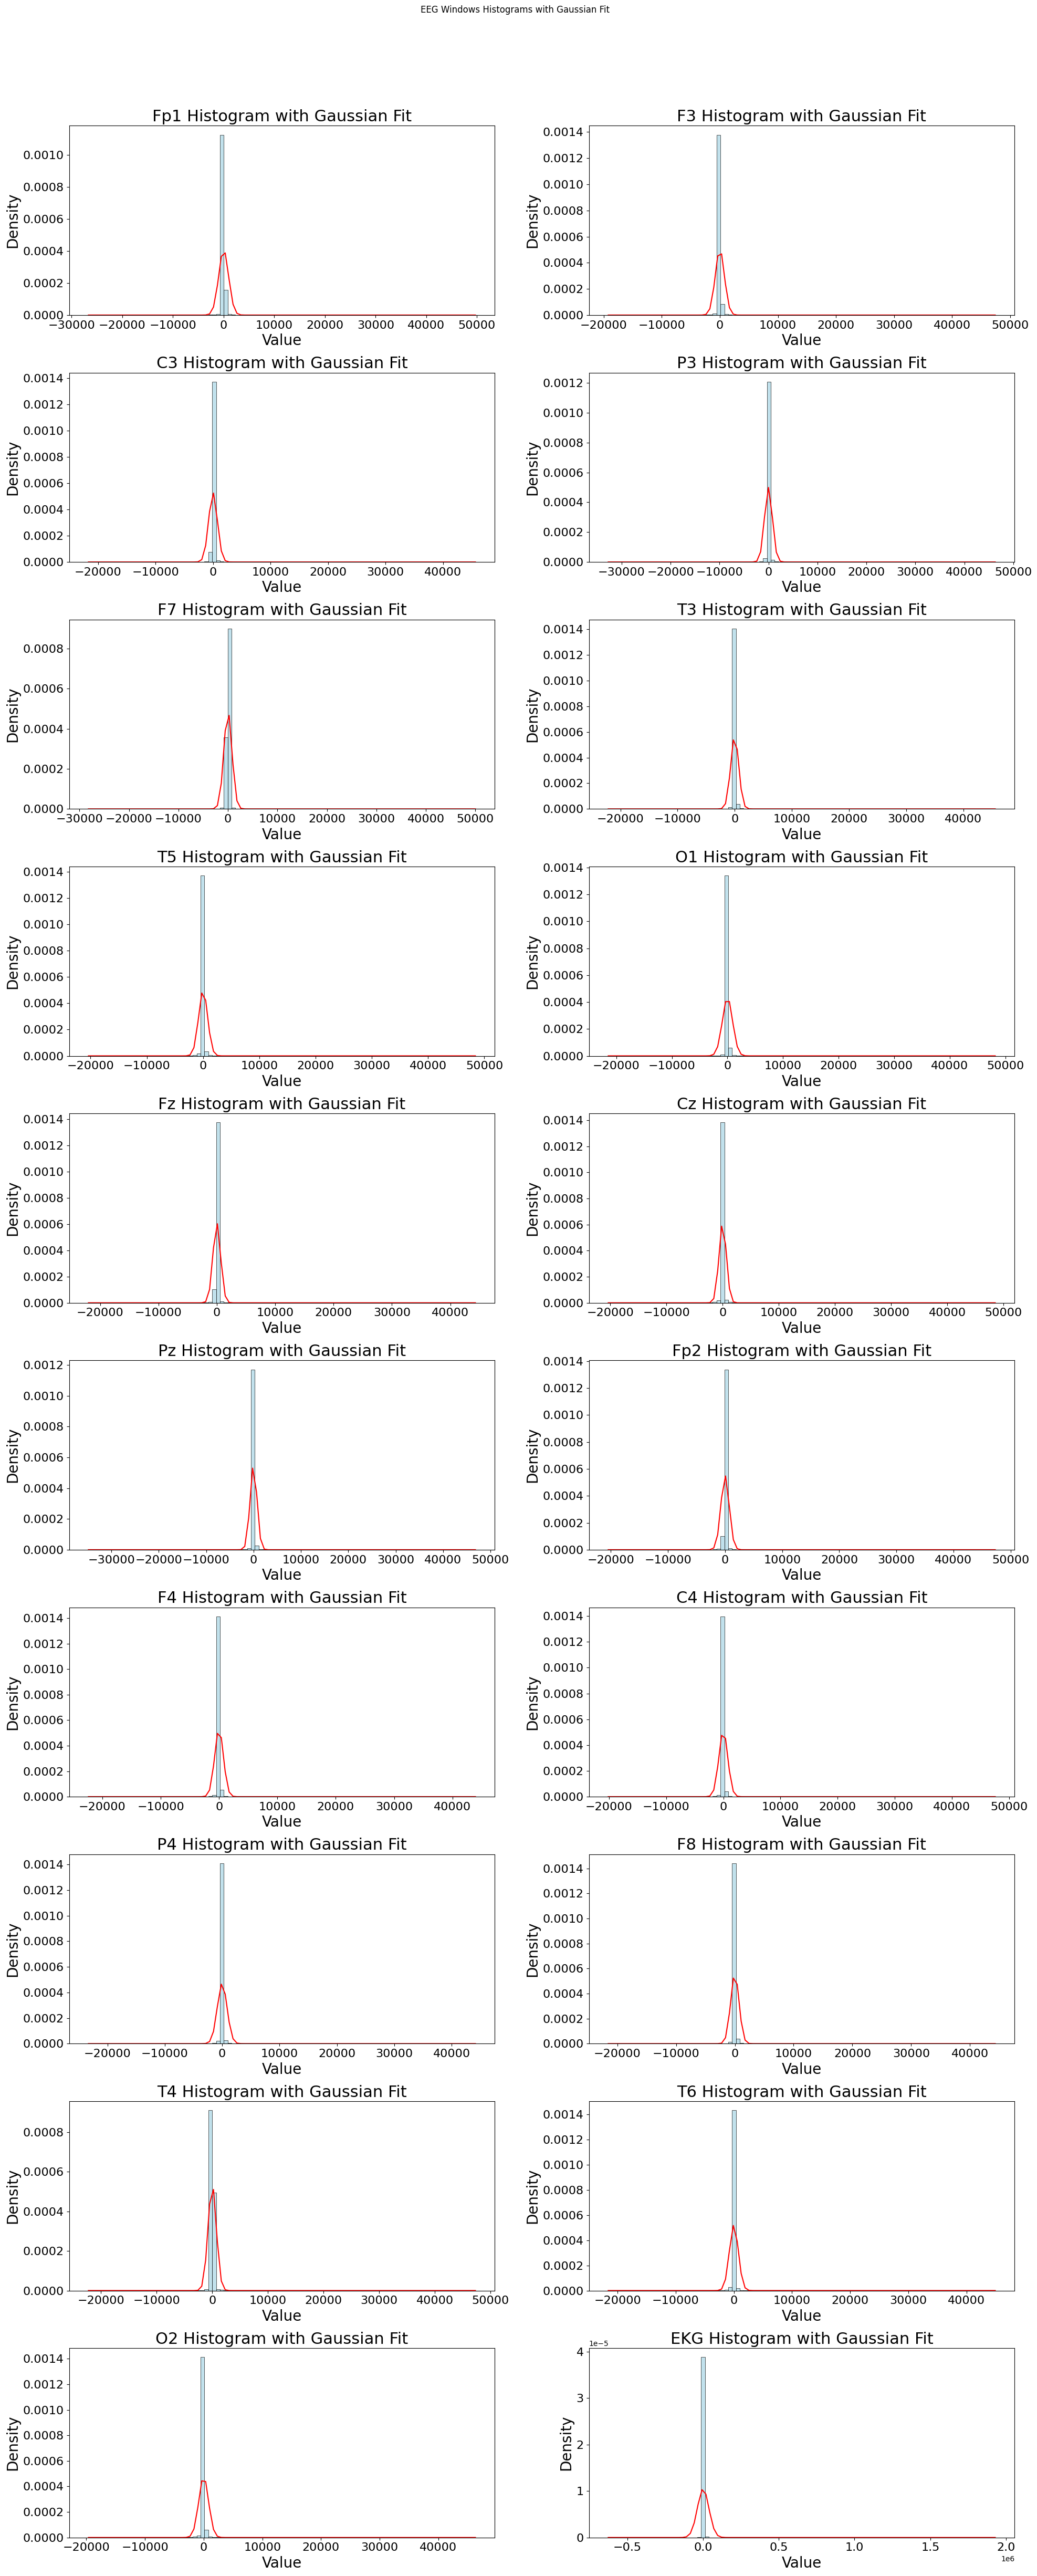

In [105]:
sampled_train_df = pd.read_csv(os.path.join(dataset_dir, "sampled_train_eegs.csv"))
eeg_windows_df = create_eeg_windows_df(sampled_train_df, eeg_windows_dir)
plot_eeg_histograms_with_gaussian(eeg_windows_df, "../scripts/EEG_windows_histograms_with_gaussian_fit.png")

In [ ]:
# EEGid and spectrogramid of the first row

GET_ROW = 0
EEG_PATH = os.path.join(dataset_dir, 'eegs/')
SPEC_PATH = os.path.join(dataset_dir, 'spectrograms/')

train = pd.read_csv('../dataset/dataset.csv')
row = train.iloc[GET_ROW]

eeg = pd.read_parquet(f'{EEG_PATH}{row.eeg_id}.parquet')
eeg_offset = int( row.eeg_label_offset_seconds )
eeg = eeg.iloc[eeg_offset*200:(eeg_offset+50)*200]

spectrogram = pd.read_parquet(f'{SPEC_PATH}{row.spectrogram_id}.parquet')
spec_offset = int( row.spectrogram_label_offset_seconds )
spectrogram = spectrogram.loc[(spectrogram.time>=spec_offset)
                     &(spectrogram.time<spec_offset+600)]

print(eeg.shape)
print(spectrogram.shape)

(10000, 20)
(300, 401)


### Filtered EEG

In [35]:
# sampled_train_df = pd.read_csv(os.path.join(dataset_dir, "sampled_train_eegs.csv"))

# #create a directory to store the filtered EEG windows
# filtered_sampled_train_eegs_dir = os.path.join(dataset_dir, "filtered_sampled_train_eegs")
# if not os.path.exists(filtered_sampled_train_eegs_dir):
#     os.makedirs(filtered_sampled_train_eegs_dir)

# #per ogni riga di sampled_train_df, carica il file csv corrispondente in filtered_eeg_windows_dir e copia il file nella cartella filtered_sampled_train_eegs
# for index, row in sampled_train_df.iterrows():
#     filename = row["label_id"]
#     eeg_window = pd.read_csv(f"{filtered_eeg_windows_dir}/{filename}.csv")
#     eeg_window.to_csv(f"{filtered_sampled_train_eegs_dir}/{filename}.csv", index=False, header=False)

In [7]:
#leggi sampled_train_df da file csv
sampled_train_df = pd.read_csv(os.path.join(dataset_dir, "sampled_train_eegs.csv"))
print(sampled_train_df.shape)

filtered_eeg_windows_df = create_eeg_windows_df(sampled_train_df, filtered_eeg_windows_dir)
filtered_eeg_windows_df.head()

(7421, 15)


KeyboardInterrupt: 

In [1]:
#save eeg_windows_df.mean() and eeg_windows_df.std() in a csv file
filtered_eeg_windows_df_mean = filtered_eeg_windows_df.mean()
filtered_eeg_windows_df_std = filtered_eeg_windows_df.std()

stats_filtered_df = pd.DataFrame({
    'Mean': filtered_eeg_windows_df_mean,
    'Std': filtered_eeg_windows_df_std
})

print("DataFrame con media e deviazione standard:\n", stats_filtered_df)

output_file_path = os.path.join(dataset_dir, f"filtered_{int(highcut)}Hz_eeg_windows_stats.csv")
stats_filtered_df.to_csv(output_file_path, index_label='Channel', header=True)

print(f"File salvato in: {output_file_path}")

NameError: name 'filtered_eeg_windows_df' is not defined

In [ ]:
plot_eeg_histograms_with_gaussian(filtered_eeg_windows_df, f"../scripts/filtered_{int(highcut)}Hz_EEG_windows_histograms_with_gaussian_fit.png")

NameError: name 'filtered_eeg_windows_df' is not defined

## Preprocessing

(2000, 20)
(2000, 20)


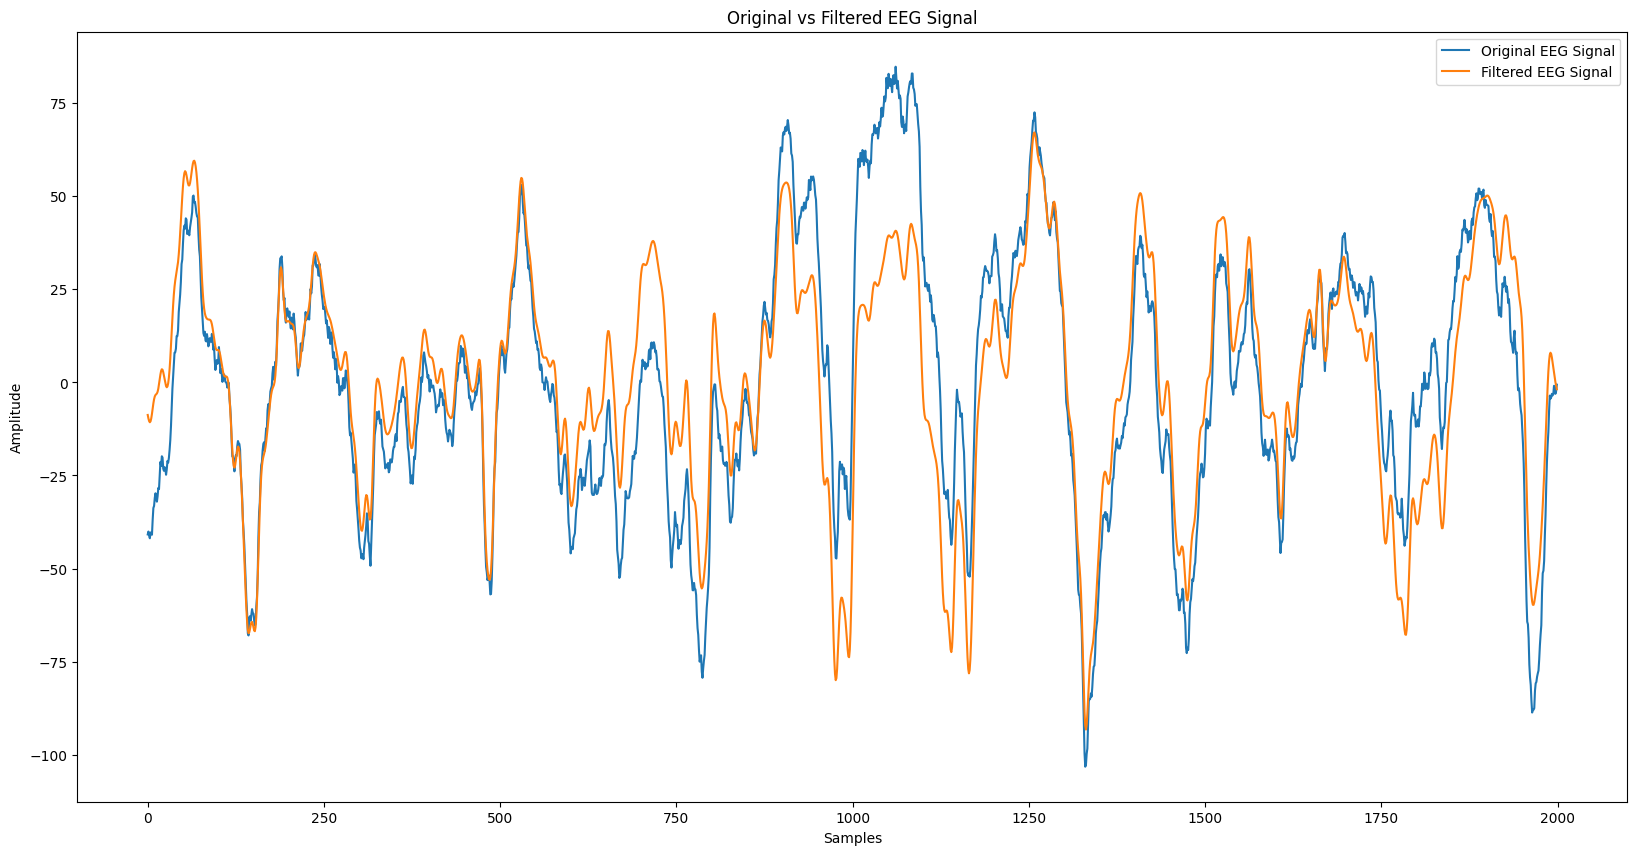

In [ ]:
# leggi train_eegs.csv, leggi la prima row, preleva il file label_id.csv da eeg_windows

train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))
row = train_eegs.iloc[0]
eeg = pd.read_csv(f'{eeg_windows_dir}/{row.label_id}.csv')
print(eeg.shape)

# filtra il segnale con un filtro passa banda tra 0.5 e 20 Hz

from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

lowcut = 0.5
highcut = 20
fs = 200
order = 5

eeg_filtered = pd.DataFrame()
for column in eeg.columns:
    eeg_filtered[column] = butter_bandpass_filter(eeg[column], lowcut, highcut, fs, order)

print(eeg_filtered.shape)   

# stampa il segnale prima e dopo per vedere la differenza

plt.figure(figsize=(20, 10))
plt.plot(eeg.iloc[:, 0], label='Original EEG Signal')
plt.plot(eeg_filtered.iloc[:, 0], label='Filtered EEG Signal')
plt.title('Original vs Filtered EEG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

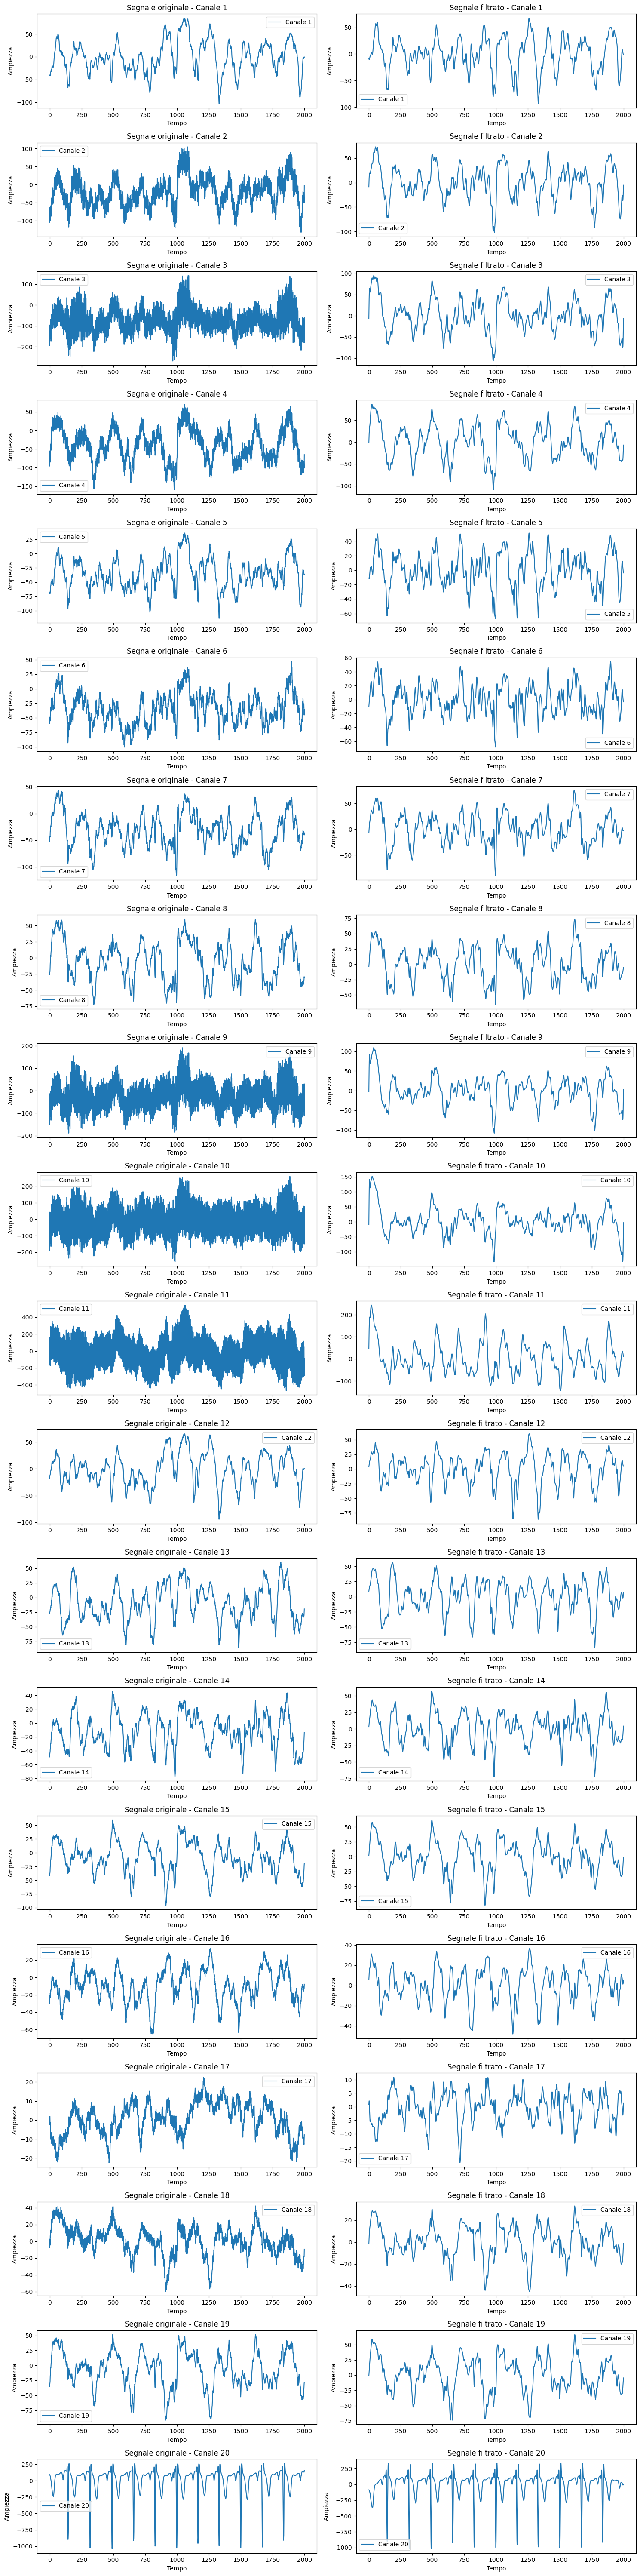

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


# Funzione per creare il filtro passabanda
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Funzione per applicare il filtro passabanda
def apply_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def plot_signals(before, after, n_channels=20):
    fig, axes = plt.subplots(n_channels, 2, figsize=(15, 3 * n_channels))
    time = np.arange(before.shape[0])
    
    for i in range(n_channels):
        axes[i, 0].plot(time, before[:, i], label=f'Canale {i+1}')
        axes[i, 0].set_title(f'Segnale originale - Canale {i+1}')
        axes[i, 0].set_xlabel('Tempo')
        axes[i, 0].set_ylabel('Ampiezza')
        axes[i, 0].legend()
        
        axes[i, 1].plot(time, after[:, i], label=f'Canale {i+1}')
        axes[i, 1].set_title(f'Segnale filtrato - Canale {i+1}')
        axes[i, 1].set_xlabel('Tempo')
        axes[i, 1].set_ylabel('Ampiezza')
        axes[i, 1].legend()
    
    plt.tight_layout()
    plt.show()

# Parametri del filtro
lowcut = 0.5
highcut = 20.0
fs = 200.0  # Frequenza di campionamento (in Hz)

train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))
row = train_eegs.iloc[0]
file_path = f'{eeg_windows_dir}/{row.label_id}.csv'

data = pd.read_csv(file_path).values

filtered_data = apply_bandpass_filter(data, lowcut, highcut, fs, order=5)

plot_signals(data, filtered_data, n_channels=data.shape[1])


In [ ]:
#read train_eegs.csv
train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))

#filtra tutto il training set
for index, row in train_eegs.iterrows():
    file_path = f'{eeg_windows_dir}/{row.label_id}.csv'
    data = pd.read_csv(file_path).values
    filtered_data = apply_bandpass_filter(data, lowcut, highcut, fs, order=5)
    new_file_path = f'{dataset_dir}/train/{row.label_id}.csv'
    np.savetxt(new_file_path, filtered_data, delimiter=",")

# #read val_eegs.csv
# val_eegs = pd.read_csv(os.path.join(dataset_dir, 'val_eegs.csv'))

# #filtra tutto il validation set
# for index, row in val_eegs.iterrows():
#     file_path = f'{eeg_windows_dir}/{row.label_id}.csv'
#     data = pd.read_csv(file_path).values
#     filtered_data = apply_bandpass_filter(data, lowcut, highcut, fs, order=5)
#     new_file_path = f'{dataset_dir}/val/{row.label_id}.csv'
#     np.savetxt(new_file_path, filtered_data, delimiter=",")

# #read test_eegs.csv
# test_eegs = pd.read_csv(os.path.join(dataset_dir, 'test_eegs.csv'))

# #filtra tutto il test set
# for index, row in test_eegs.iterrows():
#     file_path = f'{eeg_windows_dir}/{row.label_id}.csv'
#     data = pd.read_csv(file_path).values
#     filtered_data = apply_bandpass_filter(data, lowcut, highcut, fs, order=5)
#     new_file_path = f'{dataset_dir}/test/{row.label_id}.csv'
#     np.savetxt(new_file_path, filtered_data, delimiter=",")



# Vote count

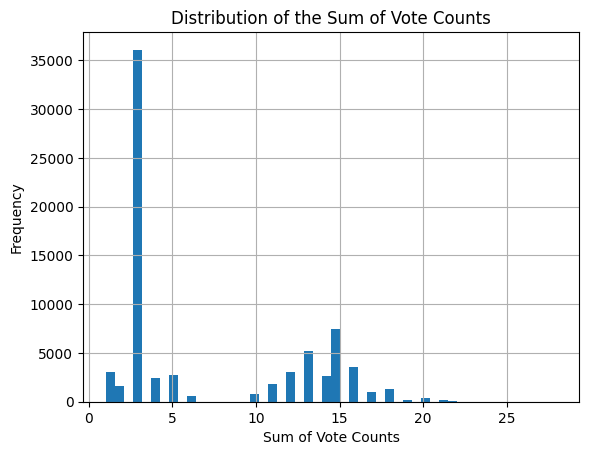

74248
69608
33517
27735


In [11]:
# leggi train_eegs.csv
train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))

# stampa la prima riga
# print(train_eegs.head(1))

# plotta la distribuzioe della somma delle colonne che finiscono per _vote
train_eegs.filter(regex='_vote$').sum(axis=1).hist(bins=50)
plt.title('Distribution of the Sum of Vote Counts')
plt.xlabel('Sum of Vote Counts')
plt.ylabel('Frequency')
plt.show()

# stampa il numero di sample in train_eegs
print(train_eegs.shape[0])
# stampa il numero di sample in train_eegs con somma delle colonne che finiscono per _vote maggiore di 3
print(train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 3].shape[0])
# stampa il numero di sample in train_eegs con somma delle colonne che finiscono per _vote maggiore di 4
print(train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 4].shape[0])
# stampa il numero di sample in train_eegs con somma delle colonne che finiscono per _vote maggiore di 10
print(train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 10].shape[0])

In [6]:
#stampa quanti sample sul totale di train_eegs, val_eegs e test_eegs hanno una somma di voti maggiore o uguale a 4
train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))
val_eegs = pd.read_csv(os.path.join(dataset_dir, 'val_eegs.csv'))
test_eegs = pd.read_csv(os.path.join(dataset_dir, 'test_eegs.csv'))

#somma totale di sample di train_eegs, val_eegs e test_eegs
print(train_eegs.shape[0] + val_eegs.shape[0] + test_eegs.shape[0])

106073


47860


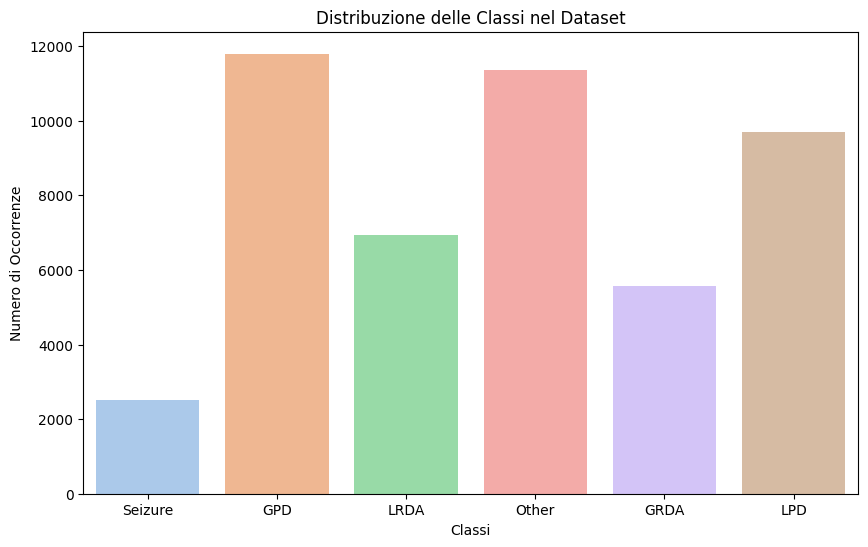

In [9]:
# somma totale di sample di train_eegs, val_eegs e test_eegs con somma di voti maggiore o uguale a 4
print(train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 4].shape[0] + val_eegs[val_eegs.filter(regex='_vote$').sum(axis=1) >= 4].shape[0] + test_eegs[test_eegs.filter(regex='_vote$').sum(axis=1) >= 4].shape[0])
# crea dataframe con sample di train_eegs, val_eegs e test_eegs con somma di voti maggiore o uguale a 4
df_eegs_vote_ge4 = pd.concat([train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 4], val_eegs[val_eegs.filter(regex='_vote$').sum(axis=1) >= 4], test_eegs[test_eegs.filter(regex='_vote$').sum(axis=1) >= 4]])
#plot class distribution of df_eegs_vote_ge4
plot_class_distribution(df_eegs_vote_ge4)
#save df_eegs_vote_ge4 to a csv file
df_eegs_vote_ge4.to_csv(os.path.join(dataset_dir, 'df_eegs_vote_ge4.csv'), index=False)

In [20]:
import pandas as pd
from sklearn.utils import resample

# Carica il dataset
df_eegs_vote_ge10 = pd.read_csv(os.path.join(dataset_dir, 'df_eegs_vote_ge10.csv'))
print("Prima del bilanciamento: ", df_eegs_vote_ge10.shape[0])
print(df_eegs_vote_ge10['expert_consensus'].value_counts())

# Determina la classe maggioritaria
max_class_count = df_eegs_vote_ge10['expert_consensus'].value_counts().max()

# Lista per raccogliere i DataFrame di ogni classe bilanciata
df_list = []

# Itera su ogni classe
for class_value in df_eegs_vote_ge10['expert_consensus'].unique():
    # Seleziona i campioni della classe corrente
    df_class = df_eegs_vote_ge10[df_eegs_vote_ge10['expert_consensus'] == class_value]
    
    # Numero di campioni da aggiungere
    n_samples_to_add = max_class_count - len(df_class)
    
    if n_samples_to_add > 0:
        # Duplica i campioni della classe corrente fino a raggiungere la dimensione della classe maggioritaria
        df_class_balanced_original = df_class.copy()  # Mantieni gli originali
        df_class_balanced_augmented = resample(df_class, 
                                               replace=True,  # Duplicazione permessa
                                               n_samples=n_samples_to_add,  # Numero di campioni da aggiungere
                                               random_state=42)  # Riproducibilità
        
        # Aggiungi la colonna "augmented"
        df_class_balanced_original['augmented'] = 0
        df_class_balanced_augmented['augmented'] = 1

        # Combina originali e duplicati
        df_class_balanced = pd.concat([df_class_balanced_original, df_class_balanced_augmented])
    else:
        # Se la classe è già bilanciata, non duplicare
        df_class_balanced = df_class.copy()
        df_class_balanced['augmented'] = 0

    # Aggiungi alla lista
    df_list.append(df_class_balanced)

# Combina tutte le classi bilanciate in un unico DataFrame
df_eegs_vote_ge10_balanced = pd.concat(df_list)

# Mostra il numero di campioni per ciascuna classe dopo il bilanciamento
print("Dopo il bilanciamento: ", df_eegs_vote_ge10_balanced.shape[0])
print(df_eegs_vote_ge10_balanced['expert_consensus'].value_counts())

# Mostra il numero di campioni originali e augmentati
print("Original samples:", df_eegs_vote_ge10_balanced[df_eegs_vote_ge10_balanced['augmented'] == 0].shape[0])
print("Augmented samples:", df_eegs_vote_ge10_balanced[df_eegs_vote_ge10_balanced['augmented'] == 1].shape[0])

# Salva il dataset bilanciato su un file CSV
# df_eegs_vote_ge10_balanced.to_csv(os.path.join(dataset_dir, 'df_eegs_vote_ge10_balanced.csv'), index=False)


Prima del bilanciamento:  39604
expert_consensus
Other      10125
GPD        10035
LPD         7353
LRDA        6167
GRDA        5334
Seizure      590
Name: count, dtype: int64
Dopo il bilanciamento:  60750
expert_consensus
Seizure    10125
GPD        10125
LRDA       10125
Other      10125
GRDA       10125
LPD        10125
Name: count, dtype: int64
Original samples: 39604
Augmented samples: 21146


39604


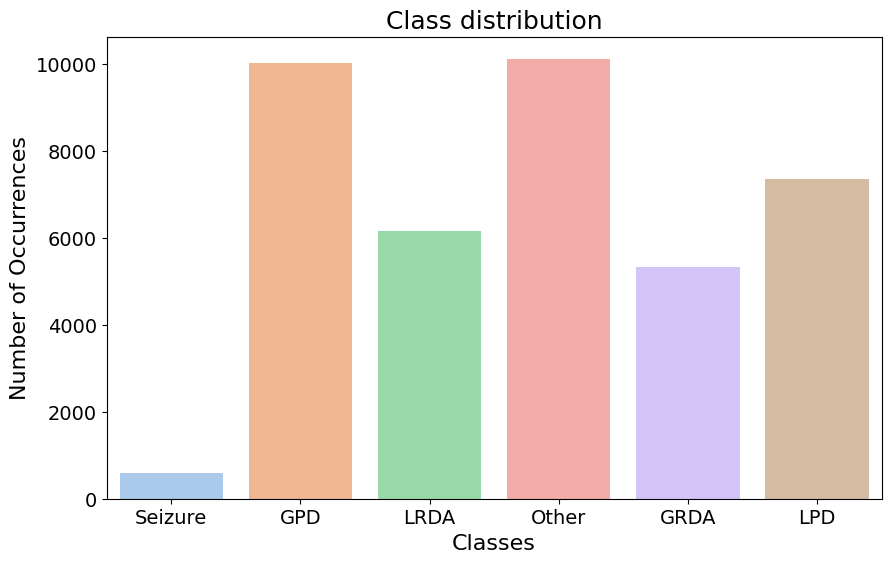

In [7]:
# somma totale di sample di train_eegs, val_eegs e test_eegs con somma di voti maggiore o uguale a 10
print(train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 10].shape[0] + val_eegs[val_eegs.filter(regex='_vote$').sum(axis=1) >= 10].shape[0] + test_eegs[test_eegs.filter(regex='_vote$').sum(axis=1) >= 10].shape[0])
# crea dataframe con sample di train_eegs, val_eegs e test_eegs con somma di voti maggiore o uguale a 10
df_eegs_vote_ge10 = pd.concat([train_eegs[train_eegs.filter(regex='_vote$').sum(axis=1) >= 10], val_eegs[val_eegs.filter(regex='_vote$').sum(axis=1) >= 10], test_eegs[test_eegs.filter(regex='_vote$').sum(axis=1) >= 10]])
#plot class distribution of df_eegs_vote_ge10
plot_class_distribution(df_eegs_vote_ge10)
#save df_eegs_vote_ge10 to a csv file
df_eegs_vote_ge10.to_csv(os.path.join(dataset_dir, 'df_eegs_vote_ge10.csv'), index=False)

Proporzioni delle classi:
expert_consensus
Other      0.255656
GPD        0.253383
LPD        0.185663
LRDA       0.155717
GRDA       0.134683
Seizure    0.014897
Name: proportion, dtype: float64


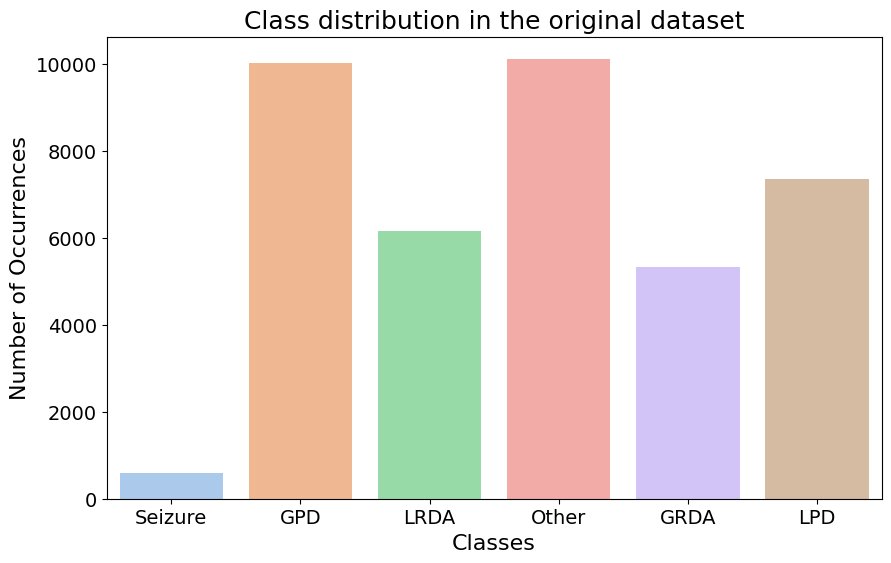

In [108]:
df_eegs_vote_ge10 = pd.read_csv(os.path.join(dataset_dir, 'df_eegs_vote_ge10.csv'))
#stampa proporzioni delle classi
print("Proporzioni delle classi:")
print(df_eegs_vote_ge10['expert_consensus'].value_counts(normalize=True))
plot_class_distribution(df_eegs_vote_ge10)

Original dataset: 39604 samples
Train set: 27720 samples
Validation set: 5940 samples
Test set: 5944 samples

--------------------------------------------------

Train set
expert_consensus
Other      0.255664
GPD        0.253391
LPD        0.185678
LRDA       0.155700
GRDA       0.134668
Seizure    0.014899
Name: proportion, dtype: float64


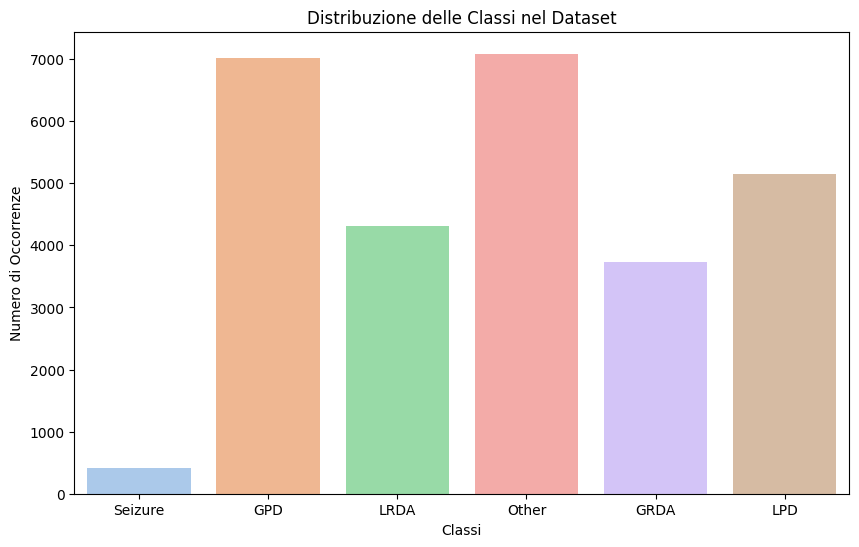

Validation set
expert_consensus
Other      0.255724
GPD        0.253367
LPD        0.185690
LRDA       0.155724
GRDA       0.134680
Seizure    0.014815
Name: proportion, dtype: float64


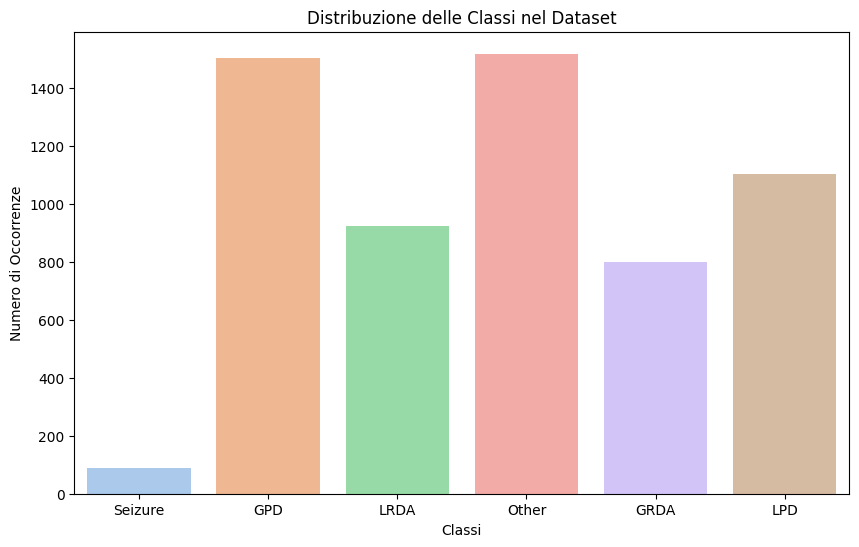

Test set
expert_consensus
Other      0.255552
GPD        0.253365
LPD        0.185565
LRDA       0.155787
GRDA       0.134758
Seizure    0.014973
Name: proportion, dtype: float64


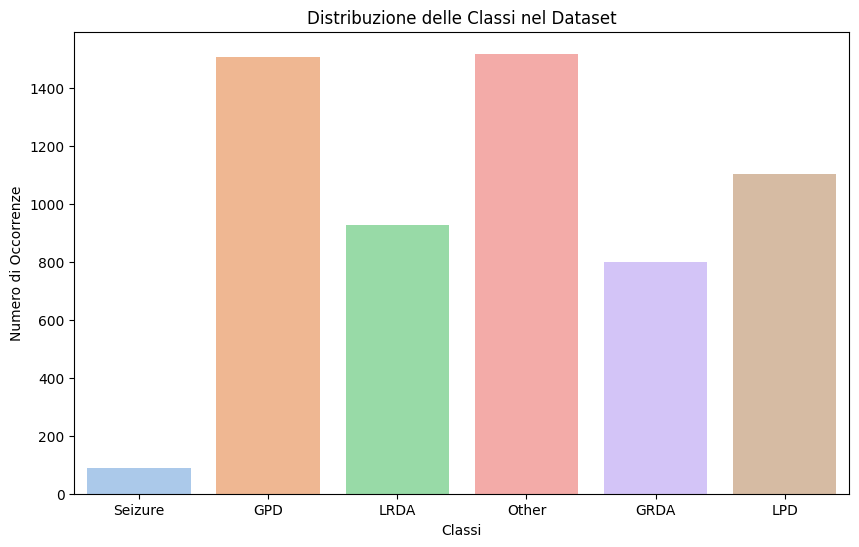

In [37]:
# read df_eegs_vote_ge10 from file
df_eegs_vote_ge10 = pd.read_csv(os.path.join(dataset_dir, 'df_eegs_vote_ge10.csv'))
train_df_10, validation_df_10, test_df_10 = split_dataset(df_eegs_vote_ge10, train_size=0.7, validation_size=0.15, test_size=0.15)

print(f"Original dataset: {df_eegs_vote_ge10.shape[0]} samples")
print(f"Train set: {train_df_10.shape[0]} samples")
print(f"Validation set: {validation_df_10.shape[0]} samples")
print(f"Test set: {test_df_10.shape[0]} samples")

print("\n" + "-"*50 + "\n")

# Stampa delle proporzioni di ogni classe
print("Train set")
print(train_df_10["expert_consensus"].value_counts(normalize=True))
plot_class_distribution(train_df_10)

print("Validation set")
print(validation_df_10["expert_consensus"].value_counts(normalize=True))
plot_class_distribution(validation_df_10)

print("Test set")
print(test_df_10["expert_consensus"].value_counts(normalize=True))
plot_class_distribution(test_df_10)

train_df_10.to_csv(os.path.join(dataset_dir, "train_hq_eegs.csv"), index=False)
validation_df_10.to_csv(os.path.join(dataset_dir, "val_hq_eegs.csv"), index=False)
test_df_10.to_csv(os.path.join(dataset_dir, "test_hq_eegs.csv"), index=False)

In [28]:
train_df_ge10 = pd.read_csv(os.path.join(dataset_dir, 'train_hq_eegs.csv'))
# per ogni classe stampa il totale di campioni
print(train_df_ge10["expert_consensus"].value_counts())
# calcola un vettore con il numero di campioni da prelevare per ogni classe (10% per classe)
n_samples_per_class = (train_df_ge10["expert_consensus"].value_counts() * 0.1).astype(int)
# stampa il vettore
print(n_samples_per_class)

expert_consensus
Other      7087
GPD        7024
LPD        5147
LRDA       4316
GRDA       3733
Seizure     413
Name: count, dtype: int64
expert_consensus
Other      708
GPD        702
LPD        514
LRDA       431
GRDA       373
Seizure     41
Name: count, dtype: int32


In [29]:
sampled_hq_train_df = prop_sample_train_dataset(train_df, n_samples_per_class)
# per ogni classe stampa il totale di campioni
print(sampled_train_df["expert_consensus"].value_counts())

sampled_train_df.to_csv(os.path.join(dataset_dir, "sampled_hq_train_eegs.csv"), index=False)

expert_consensus
Seizure    1460
GRDA       1310
Other      1305
GPD        1163
LRDA       1153
LPD        1030
Name: count, dtype: int64


# Ideal patterns

In [25]:
# leggi dataset
dataset_df = pd.read_csv(os.path.join(dataset_dir, "df_eegs_vote_ge4.csv"))
print(dataset_df.shape[0])
print(f"Numero di righe nel dataset: {dataset_df.shape[0]}")

# Filtra le colonne che finiscono con _vote
vote_columns = [col for col in dataset_df.columns if col.endswith('_vote')]
# Ottieni il nome della colonna corrispondente a "expert_consensus"_vote (convertito a lowercase)
label_vote_column = f"{dataset_df['expert_consensus'].iloc[0].lower()}_vote"
# Filtra il dataset per le righe che soddisfano le condizioni
ideal_votes = dataset_df[
    (dataset_df[label_vote_column] != 0) & 
    (dataset_df[vote_columns].drop(columns=[label_vote_column]) == 0).all(axis=1)
]

# Stampa il numero di sample nel dataset filtrato
print(f"Numero di sample nel dataset filtrato: {ideal_votes.shape[0]}")
# Stampa un sample del dataset filtrato
print(ideal_votes.head())

47860
Numero di righe nel dataset: 47860
Numero di sample nel dataset filtrato: 473
        eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
5   2147495892           4                      18.0       386966986   
13  1655747098           6                      88.0      2063549775   
30  3608565308          10                      42.0       116393433   
33  3158461194           3                      20.0      1439070338   
48  3245328542           0                       0.0       805745423   

    spectrogram_sub_id  spectrogram_label_offset_seconds    label_id  \
5                    4                              18.0  2752832790   
13                   6                              88.0  4159159971   
30                  10                              42.0  2261764431   
33                   3                              20.0  2031821471   
48                   8                            1806.0   618708943   

    patient_id expert_consensus  seizure_vote  lpd

# Spectrogram analysis

In [4]:
df_eeg = pd.read_parquet(os.path.join(dataset_dir, "spectrograms", "353733.parquet"))
df_eeg.head(10)

,time,LL_0.59,LL_0.78,LL_0.98,LL_1.17,LL_1.37,LL_1.56,LL_1.76,LL_1.95,LL_2.15,...,RP_18.16,RP_18.36,RP_18.55,RP_18.75,RP_18.95,RP_19.14,RP_19.34,RP_19.53,RP_19.73,RP_19.92
0,1,4.26,10.98,9.05,13.65,11.49,8.930000,18.840000,19.260000,19.240000,...,0.31,0.17,0.28,0.19,0.24,0.27,0.29,0.16,0.22,0.19
1,3,2.65,3.97,12.18,13.26,14.21,13.230000,9.650000,8.110000,11.280000,...,0.15,0.13,0.14,0.24,0.24,0.36,0.35,0.31,0.36,0.40
2,5,4.18,4.53,8.77,14.26,13.36,16.559999,19.219999,17.510000,22.650000,...,0.29,0.21,0.16,0.25,0.28,0.28,0.34,0.48,0.44,0.48
3,7,2.41,3.21,4.92,8.07,5.97,12.420000,10.820000,14.960000,21.809999,...,0.33,0.51,0.49,0.64,0.58,0.42,0.32,0.31,0.32,0.33
4,9,2.29,2.44,2.77,4.62,5.39,7.080000,9.840000,12.270000,14.410000,...,0.44,0.38,0.48,0.63,0.45,0.45,0.49,0.33,0.31,0.34
5,11,2.77,3.50,5.17,4.29,4.45,6.990000,8.960000,7.870000,18.200001,...,0.36,0.33,0.48,0.23,0.24,0.22,0.22,0.18,0.16,0.27
6,13,2.87,3.45,3.10,3.94,8.17,11.740000,14.710000,18.590000,24.660000,...,0.39,0.40,0.38,0.52,0.46,0.33,0.35,0.18,0.23,0.23
7,15,3.86,4.07,4.26,6.46,8.06,11.390000,9.600000,16.530001,23.459999,...,0.36,0.39,0.50,0.53,0.43,0.48,0.33,0.24,0.18,0.20
8,17,9.33,11.45,12.28,11.26,7.21,3.620000,8.970000,12.920000,17.389999,...,0.35,0.38,0.32,0.31,0.43,0.22,0.26,0.30,0.28,0.25
9,19,7.39,11.34,12.52,12.49,14.19,11.720000,15.290000,19.510000,24.830000,...,0.26,0.38,0.32,0.29,0.26,0.18,0.18,0.26,0.31,0.36


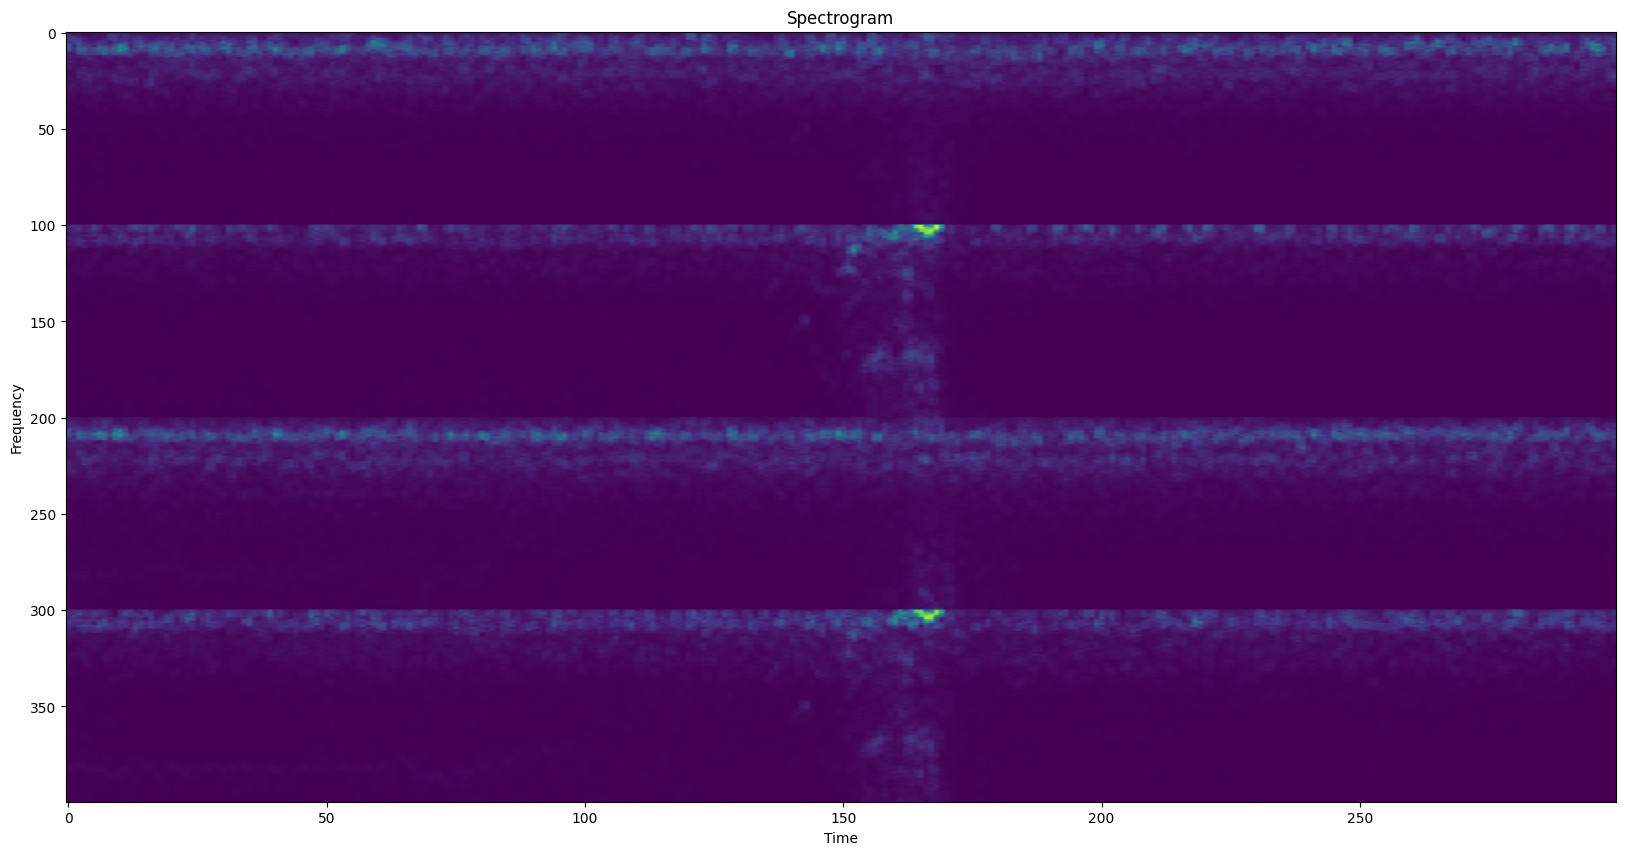

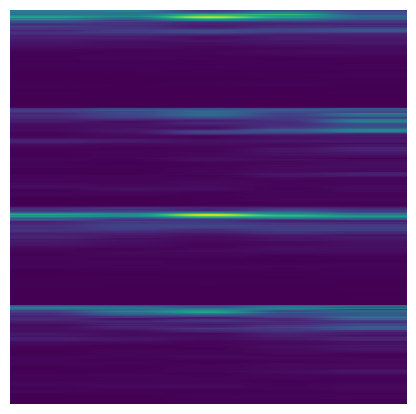

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

GET_ROW = 0
dataset_dir = '../dataset'
train = pd.read_csv(os.path.join(dataset_dir, 'dataset.csv'))
row = train.iloc[GET_ROW]

EEG_PATH = os.path.join(dataset_dir, 'eegs/')
SPEC_PATH = os.path.join(dataset_dir, 'spectrograms/')

# Read EEG and spectrogram of the first row
eeg = pd.read_parquet(f'{EEG_PATH}{row.eeg_id}.parquet')
eeg_offset = int(row.eeg_label_offset_seconds)
eeg = eeg.iloc[eeg_offset * 200:(eeg_offset + 50) * 200]

spectrogram = pd.read_parquet(f'{SPEC_PATH}{row.spectrogram_id}.parquet')
spec_offset = int(row.spectrogram_label_offset_seconds)
spectrogram = spectrogram.loc[(spectrogram.time >= spec_offset) & (spectrogram.time < spec_offset + 600)]

class_names = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']
label2name = dict(enumerate(class_names))
name2label = {v: k for k, v in label2name.items()}

#plot spectrogram
plt.figure(figsize=(20, 10))
plt.imshow(spectrogram.iloc[:, 1:].T, aspect='auto', cmap='viridis')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

#ora plotta solo i 10 secondi centrali dello spettrogramma
plt.figure(figsize=(5.12, 5.12), dpi=100)  # 512x512 pixels
plt.imshow(spectrogram.loc[(spectrogram.time >= spec_offset + 295) & (spectrogram.time < spec_offset + 305)].iloc[:, 1:].T, aspect='auto', cmap='viridis')
plt.axis('off')  # Remove axes
central_spec = spectrogram.loc[(spectrogram.time >= spec_offset + 295) & (spectrogram.time < spec_offset + 305)].iloc[:, 1:].T


In [7]:
#plot central_spec augmented with MixUp and RandomCutout augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

# Define the augmentation pipeline
augmentation_pipeline = A.Compose([
    A.Mixup(p=1),
    A.RandomCrop(512, 512, p=1),
    ToTensorV2()
])

# Apply the augmentation pipeline to the central spectrogram
augmented = augmentation_pipeline(image=central_spec.values)
augmented_spec = augmented['image']

# Plot the augmented spectrogram
plt.figure(figsize=(5.12, 5.12), dpi=100)
plt.imshow(augmented_spec.squeeze(), aspect='auto', cmap='viridis')
plt.axis('off')
plt.show()

ModuleNotFoundError: No module named 'albumentations'

# Hybrid dataset

In [18]:
# leggi train_eegs.csv, test_eegs.csv e val_eegs.csv
train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))
test_eegs = pd.read_csv(os.path.join(dataset_dir, 'test_eegs.csv'))
val_eegs = pd.read_csv(os.path.join(dataset_dir, 'val_eegs.csv'))

# crea un dataframe con la concatenazione di train_eegs, test_eegs e val_eegs
df_eegs = pd.concat([train_eegs, test_eegs, val_eegs])

# stampa la dimensione del dataframe
print(df_eegs.shape)

#leggi train_spectr.csv, test_spectr.csv e val_spectr.csv
train_spectr = pd.read_csv(os.path.join(dataset_dir, 'train_spectr.csv'))
test_spectr = pd.read_csv(os.path.join(dataset_dir, 'test_spectr.csv'))
val_spectr = pd.read_csv(os.path.join(dataset_dir, 'val_spectr.csv'))

# crea un dataframe con la concatenazione di train_spectr, test_spectr e val_spectr
df_spectr = pd.concat([train_spectr, test_spectr, val_spectr])

# stampa la dimensione del dataframe
print(df_spectr.shape)

#crea un dataframe che prende le row con label_id in comune tra df_eegs e df_spectr
common_df = df_eegs[df_eegs['label_id'].isin(df_spectr['label_id'])]

# stampa la dimensione del dataframe
print(common_df.shape)

# leggi train_eegsspectr.csv, test_eegsspectr.csv e val_eegsspectr.csv da old_dataset_dir
train_eegsspectr = pd.read_csv(os.path.join(old_dataset_dir, 'train_eegsspectr.csv'))
test_eegsspectr = pd.read_csv(os.path.join(old_dataset_dir, 'test_eegsspectr.csv'))
val_eegsspectr = pd.read_csv(os.path.join(old_dataset_dir, 'val_eegsspectr.csv'))

# crea un dataframe con la concatenazione di train_eegsspectr, test_eegsspectr e val_eegsspectr
df_eegsspectr = pd.concat([train_eegsspectr, test_eegsspectr, val_eegsspectr])

# stampa la dimensione del dataframe
print(df_eegsspectr.shape)

#assert che il numero di righe di df_eegsspectr sia uguale a common_df
assert df_eegsspectr.shape[0] == common_df.shape[0]

# split common_df in train, validation e test set
train_df, validation_df, test_df = split_dataset(common_df, train_size=0.7, validation_size=0.15, test_size=0.15)

print(f"Original dataset: {common_df.shape[0]} samples")
print(f"Train set: {train_df.shape[0]} samples")
print(f"Validation set: {validation_df.shape[0]} samples")
print(f"Test set: {test_df.shape[0]} samples")

# salva train_df, validation_df e test_df in un file csv
train_df.to_csv(os.path.join(dataset_dir, "train_eegsspectr.csv"), index=False)
validation_df.to_csv(os.path.join(dataset_dir, "val_eegsspectr.csv"), index=False)
test_df.to_csv(os.path.join(dataset_dir, "test_eegsspectr.csv"), index=False)

(106073, 15)
(106644, 15)
(105956, 15)
(105956, 15)
Original dataset: 105956 samples
Train set: 74166 samples
Validation set: 15893 samples
Test set: 15897 samples


# Augmentation

Using device: cuda


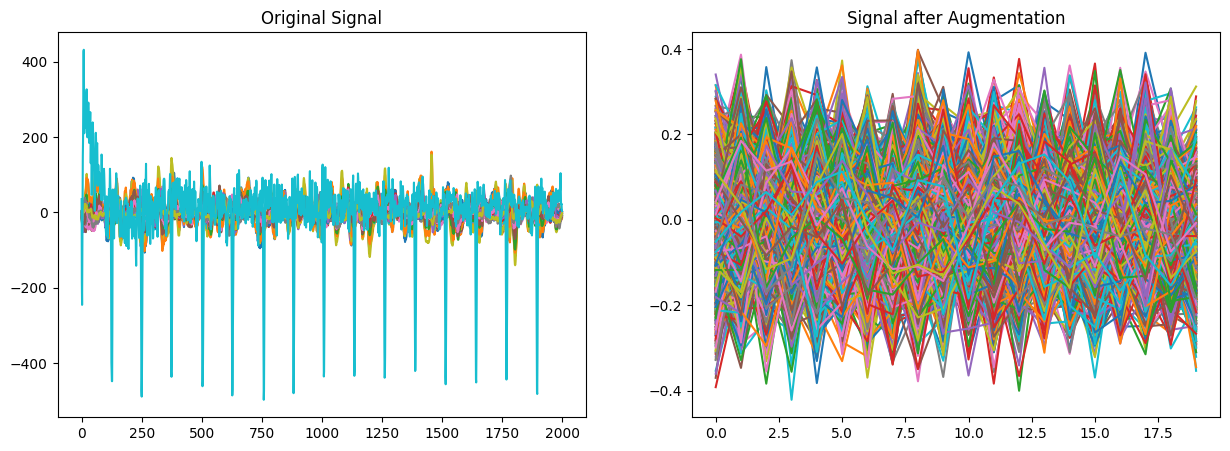

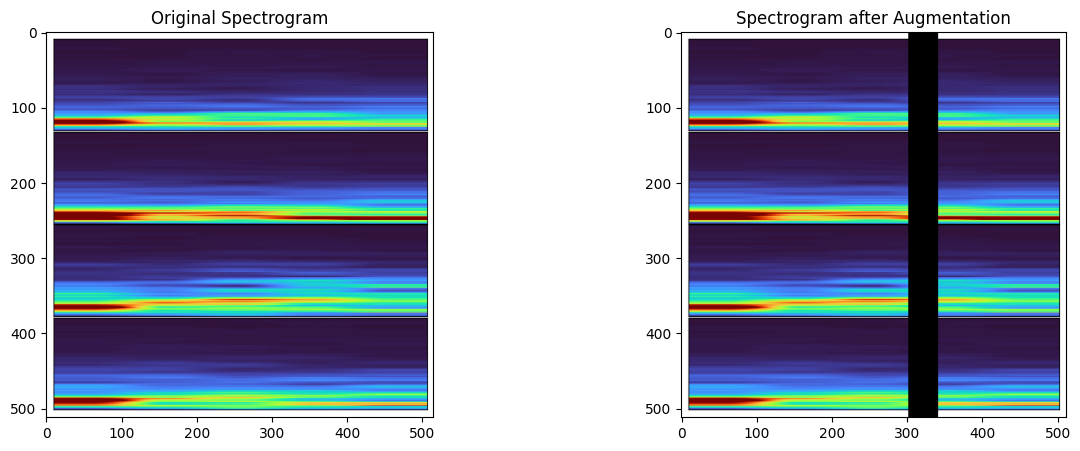

In [10]:
import numpy as np
import torch
import pandas as pd
import os
import cv2

import torchvision.transforms as transforms
import matplotlib.pyplot as plt
# !pip uninstall opencv-python opencv-python-headless
# !pip install opencv-python opencv-python-headless
import albumentations as A

from PIL import Image

class RandomTimeShift:
    def __init__(self, max_shift_sec=5):
        self.max_shift_sec = max_shift_sec

    def __call__(self, waveform, sample_rate=200):
        max_shift = int(self.max_shift_sec * sample_rate)
        shift = np.random.randint(-max_shift, max_shift)
        return torch.roll(waveform, shifts=shift, dims=1)

class RandomHorizontalFlipTime:
    def __call__(self, waveform):
        return waveform.flip(dims=[1])

class AddGaussianNoise:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, waveform):
        noise = torch.normal(self.mean, self.std, size=waveform.size()).to(waveform.device)
        return waveform + noise

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

dataset_type = 'full'
eeg_stats = os.path.join(dataset_dir, 'eeg_windows_stats.csv')
eeg_stats_ge4 = os.path.join(dataset_dir, 'eeg_windows_stats_ge4.csv')
eeg_stats_hq = os.path.join(dataset_dir, 'eeg_windows_stats_hq.csv')

if dataset_type == 'full':
    eegs_stats = pd.read_csv(eeg_stats)
elif dataset_type == 'ge4':
    eegs_stats = pd.read_csv(eeg_stats_ge4)
elif dataset_type == 'hq':
    eegs_stats = pd.read_csv(eeg_stats_hq)

eegs_train_mean = torch.tensor(eegs_stats['Mean'].values, dtype=torch.float32).to(device)
eegs_train_std = torch.tensor(eegs_stats['Std'].values, dtype=torch.float32).to(device)

def scale(x):
    x = (x - eegs_train_mean) / eegs_train_std
    return x.T.float()

def mask(image):
    image = np.array(image)
    image = A.XYMasking(num_masks_x=1, mask_x_length=(20, 40), fill_value=0, p=0.5)(image=image)
    return Image.fromarray(image['image'])


eeg_augment = transforms.Compose([
    scale,
    RandomTimeShift(max_shift_sec=5),
    RandomHorizontalFlipTime(),
    AddGaussianNoise(mean=0.0, std=0.1)
])

spectr_augment = transforms.Compose([
    mask,
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    # transforms.RandomErasing(p=0.5, scale=(0.01, 0.05), ratio=(0.5, 2.0), value=0),
    # transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.5, 1.5), value=0),
    # transforms.RandomHorizontalFlip(),
])

# Carica un esempio di input e spettrogramma
eeg_file = os.path.join(dataset_dir, f"filtered_eeg_windows_60Hz/338.csv")
eeg_df = pd.read_csv(eeg_file)
eeg = torch.tensor(eeg_df.values).float().to(device)

spectr_file = os.path.join(dataset_dir, "spectr_windows", "338.png")
image = Image.open(spectr_file).convert('RGB')

# Applica l'augmentation agli esempi di input
eeg_augmented = eeg_augment(eeg)
spectr_augmented = spectr_augment(image)

# Converti i tensori per la visualizzazione
eeg_augmented_cpu = eeg_augmented.cpu().numpy()
spectr_augmented_cpu = spectr_augmented.permute(1, 2, 0).cpu().numpy()

# Plotta segnale originale e segnale dopo l'augmentation
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot del segnale originale
axs[0].plot(eeg.cpu().numpy())
axs[0].set_title('Original Signal')

# Plot del segnale dopo l'augmentation
axs[1].plot(eeg_augmented_cpu)
axs[1].set_title('Signal after Augmentation')

# Mostra i risultati dell'augmentation per lo spettrogramma
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot dello spettrogramma originale (immagine)
axs[0].imshow(image)
axs[0].set_title('Original Spectrogram')

# Plot dello spettrogramma dopo l'augmentation
axs[1].imshow(spectr_augmented_cpu)
axs[1].set_title('Spectrogram after Augmentation')

plt.show()



<class 'PIL.Image.Image'>
<class 'numpy.ndarray'>


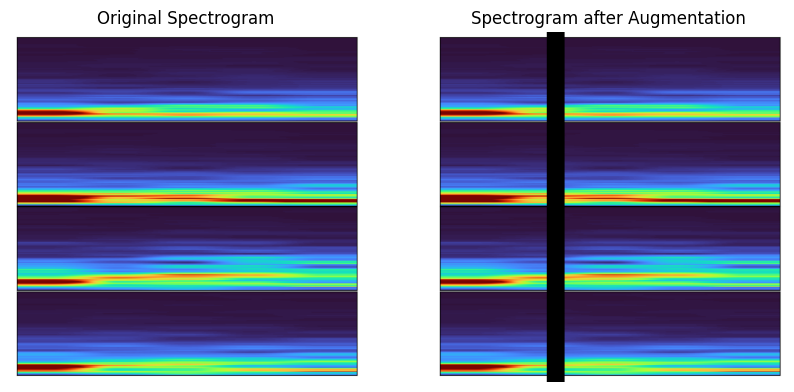

In [28]:
# apply XYMasking oof albumeentation library to an image and show before and after
import albumentations as A
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load an example image
image_path = os.path.join(dataset_dir, "spectr_windows", "338.png")
image = Image.open(image_path).convert('RGB')

#stampa tipo di image   
print(type(image))
print(type(np.array(image)))

# Define the augmentation pipeline
augmentation_pipeline = A.Compose([
    A.XYMasking(num_masks_x=1, mask_x_length=(20, 40), fill_value=0, p=1)
])

# Apply the augmentation pipeline to the image
augmented = augmentation_pipeline(image=np.array(image))
augmented_image = Image.fromarray(augmented['image'])

# Plot the original and augmented images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(image)
axs[0].set_title('Original Spectrogram')
axs[0].axis('off')

axs[1].imshow(augmented_image)
axs[1].set_title('Spectrogram after Augmentation')
axs[1].axis('off')

plt.show()

Using device: cuda


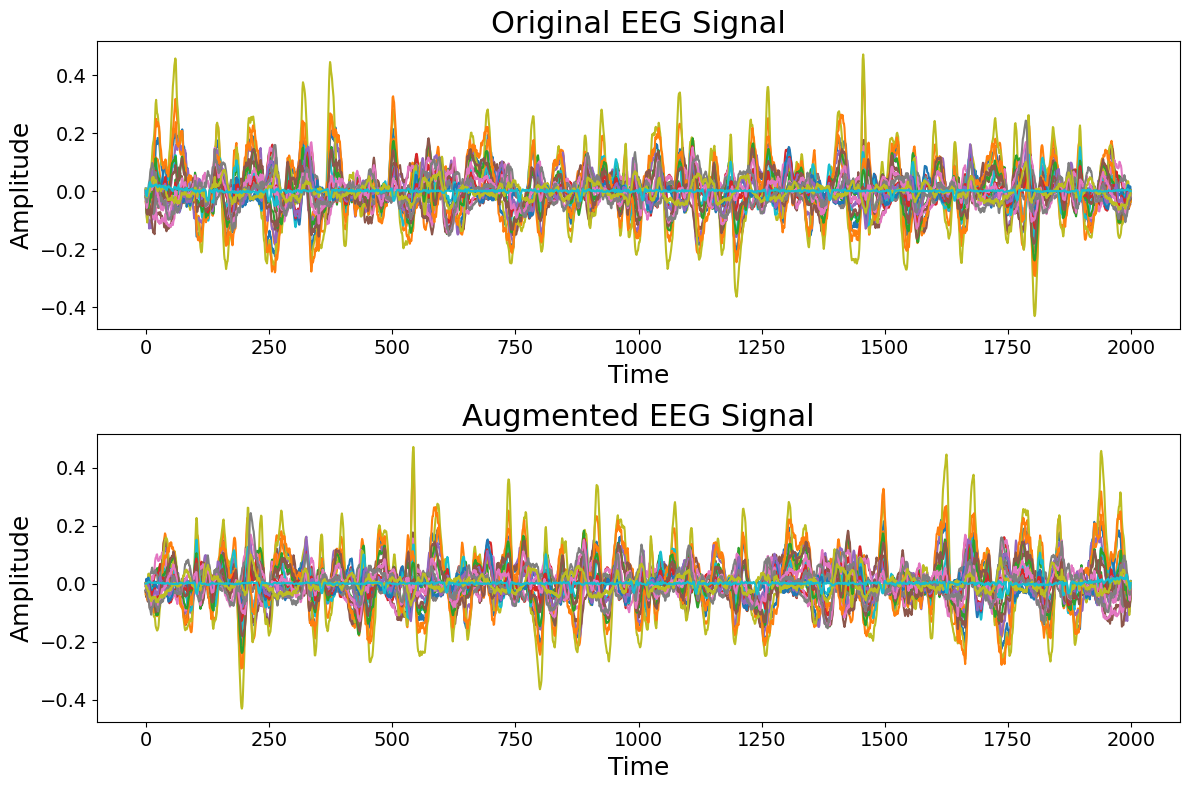

In [12]:
import numpy as np
import torch
import pandas as pd
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


class RandomTimeShift:
    def __init__(self, max_shift_sec=5):
        self.max_shift_sec = max_shift_sec

    def __call__(self, waveform, sample_rate=200):
        max_shift = int(self.max_shift_sec * sample_rate)
        shift = np.random.randint(-max_shift, max_shift)
        print(f"Applying a time shift of {shift} samples")
        return torch.roll(waveform, shifts=shift, dims=1)

class RandomHorizontalFlipTime:
    def __call__(self, waveform):
        return waveform.flip(dims=[1])

class AddGaussianNoise:
    def __init__(self, mean=0.0, std=1.0):
        self.mean = mean
        self.std = std

    def __call__(self, waveform):
        noise = torch.normal(self.mean, self.std, size=waveform.size()).to(waveform.device)
        return waveform + noise

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

dataset_type = 'full'
eeg_stats = os.path.join(dataset_dir, 'filtered_60Hz_eeg_windows_stats.csv')
eeg_stats_ge4 = os.path.join(dataset_dir, 'filtered_60Hz_ge4_eeg_windows_stats.csv')
eeg_stats_hq = os.path.join(dataset_dir, 'filtered_60Hz_hq_eeg_windows_stats.csv')

if dataset_type == 'full':
    eegs_stats = pd.read_csv(eeg_stats)
elif dataset_type == 'ge4':
    eegs_stats = pd.read_csv(eeg_stats_ge4)
elif dataset_type == 'hq':
    eegs_stats = pd.read_csv(eeg_stats_hq)

eegs_train_mean = torch.tensor(eegs_stats['Mean'].values, dtype=torch.float32).to(device)
eegs_train_std = torch.tensor(eegs_stats['Std'].values, dtype=torch.float32).to(device)
eegs_train_min = torch.tensor(eegs_stats['Min'].values, dtype=torch.float32).to(device)
eegs_train_max = torch.tensor(eegs_stats['Max'].values, dtype=torch.float32).to(device)

def scale(x):
    x = (x - eegs_train_mean) / eegs_train_std
    return x.T.float()

def min_max_scale(x):
    x = (x - eegs_train_min) / (eegs_train_max - eegs_train_min)
    return x.T.float()

eeg_augment = transforms.Compose([
    scale,
    # min_max_scale,
    # RandomTimeShift(max_shift_sec=5),
    RandomHorizontalFlipTime(),
    # AddGaussianNoise(mean=0.0, std=0.05)
])

# Carica un esempio di input e spettrogramma
eeg_file = os.path.join(dataset_dir, f"filtered_eeg_windows_60Hz/338.csv")
eeg_df = pd.read_csv(eeg_file)
eeg = torch.tensor(eeg_df.values).float().to(device)

# Applica l'augmentation agli esempi di input
eeg_augmented = eeg_augment(eeg)

# Converti i tensori per la visualizzazione
eeg = scale(eeg)
# eeg = min_max_scale(eeg)
eeg_cpu = eeg.cpu().numpy()
eeg_augmented_cpu = eeg_augmented.cpu().numpy()

# Visualizza i segnali EEG
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Plot del segnale EEG originale
axs[0].plot(eeg_cpu.T)  # Assumendo che l'asse 1 sia il tempo
axs[0].set_title('Original EEG Signal', fontsize=22)
axs[0].set_xlabel('Time', fontsize=18)
axs[0].set_ylabel('Amplitude', fontsize=18)
axs[0].tick_params(axis='both', which='major', labelsize=14)

# Plot del segnale EEG dopo l'augmentation
axs[1].plot(eeg_augmented_cpu.T)  # Assumendo che l'asse 1 sia il tempo
axs[1].set_title('Augmented EEG Signal', fontsize=22)
axs[1].set_xlabel('Time', fontsize=18)
axs[1].set_ylabel('Amplitude', fontsize=18)
axs[1].tick_params(axis='both', which='major', labelsize=14)


plt.tight_layout()

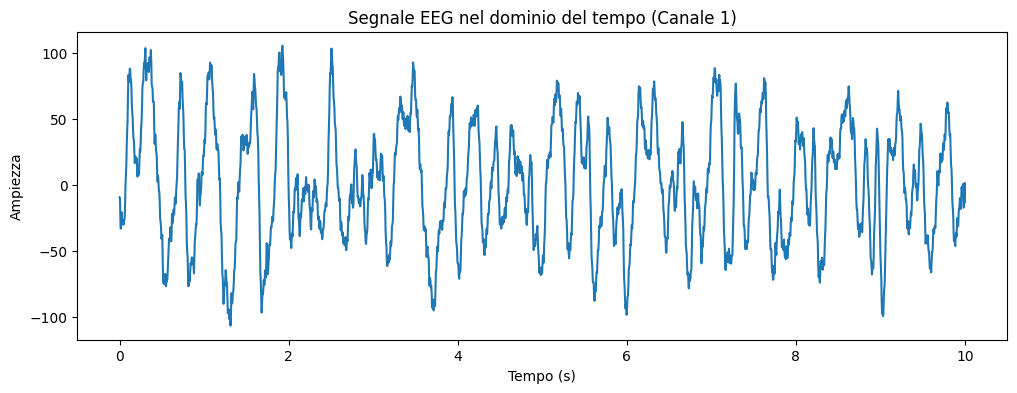

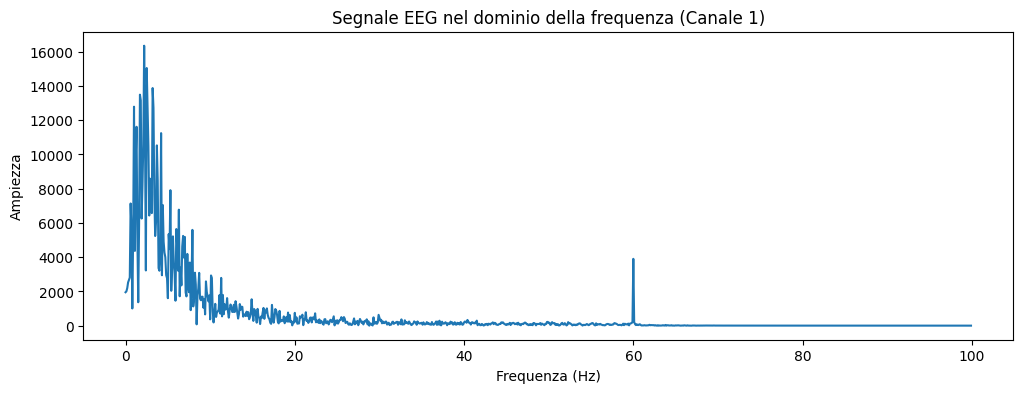

In [5]:
import numpy as np
import torch
import pandas as pd
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

dataset_dir = '../dataset'
# Carica un esempio di segnale
eeg_file = os.path.join(dataset_dir, f"filtered_eeg_windows_60Hz/338.csv")
eeg_df = pd.read_csv(eeg_file)

signal = eeg_df.values

# Frequenza di campionamento
sampling_rate = 200  # 200 Hz
t = np.linspace(0, len(signal)/sampling_rate, len(signal))

# Visualizza il segnale nel dominio del tempo (ad esempio, canale 1)
plt.figure(figsize=(12, 4))
plt.plot(t, signal[:, 0])
plt.title("Segnale EEG nel dominio del tempo (Canale 1)")
plt.xlabel("Tempo (s)")
plt.ylabel("Ampiezza")
plt.show()

# Applicazione della FFT
fft_signal = np.abs(np.fft.fft(signal, axis=0))

# Consideriamo solo la prima metà delle frequenze (componente positiva)
freqs = np.fft.fftfreq(len(t), d=1/sampling_rate)
fft_signal = fft_signal[:len(freqs)//2, :]
freqs = freqs[:len(freqs)//2]

# Visualizza il segnale nel dominio della frequenza (ad esempio, canale 1)
plt.figure(figsize=(12, 4))
plt.plot(freqs, fft_signal[:, 0])
plt.title("Segnale EEG nel dominio della frequenza (Canale 1)")
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza")
plt.show()

# Votes tensor

In [19]:
import pandas as pd
import torch
import torch.nn.functional as F

# Load the CSV file
train_eegs = pd.read_csv(os.path.join(dataset_dir, 'train_eegs.csv'))

# Print the first row
print(train_eegs.head(1))

# Print the type of the 'gpd_vote' column
print(train_eegs['gpd_vote'].dtype)

# Select only the numeric columns (e.g., seizure_vote, lpd_vote, gpd_vote, etc.)
numeric_columns = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']

# Create a tensor with the numeric values of the first row
votes = torch.tensor(train_eegs[numeric_columns].iloc[0].values, dtype=torch.float32)
probabilities = F.softmax(votes, dim=0)
#stampa tipo di votes e probabilities

# Print the tensor
print(votes)
print(probabilities)


       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  2260179574           0                       0.0      2021412740   

   spectrogram_sub_id  spectrogram_label_offset_seconds    label_id  \
0                   8                             354.0  3879179097   

   patient_id expert_consensus  seizure_vote  lpd_vote  gpd_vote  lrda_vote  \
0       26091          Seizure             3         0         0          0   

   grda_vote  other_vote  
0          0           0  
int64
tensor([3., 0., 0., 0., 0., 0.])
tensor([0.8007, 0.0399, 0.0399, 0.0399, 0.0399, 0.0399])


# Apply transformation on 1D signals

         Fp1         F3         C3        P3         F7         T3         T5  \
0  -9.494324 -13.713043  -2.715707  2.047714  -9.643636  -3.270124  -1.738982   
1  -9.933138 -22.730638 -16.029845 -6.137412 -23.437925 -17.351452 -12.011870   
2 -26.551521 -29.176392 -22.442667 -9.994956 -35.305753 -22.186894 -13.590890   
3 -33.292848 -28.533860 -22.126921 -9.878829 -39.524132 -24.279273 -12.212448   
4 -22.146913 -23.468431 -18.679813 -8.135928 -35.346555 -26.610111 -12.623740   

         O1         Fz         Cz         Pz        Fp2         F4         C4  \
0  1.218305 -12.128803  -1.447163   3.898854  -6.515102  -6.734038   0.077976   
1 -3.732429 -18.067352 -11.758315   0.509092  -7.224941 -22.423586 -12.667274   
2 -0.474253 -30.026411 -20.886208  -9.415911 -22.697120 -31.147020 -18.777517   
3  3.674645 -35.131111 -24.697352 -13.441537 -28.973714 -31.535632 -18.177211   
4  2.408837 -27.163717 -21.924558  -6.591943 -17.785868 -28.726864 -14.515377   

          P4         F8   

c:\Users\marti\Documents\GitHub\HMS-kaggle-competition\env\lib\site-packages\pywt\_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


Shape of CWT results: (20, 64, 2000)


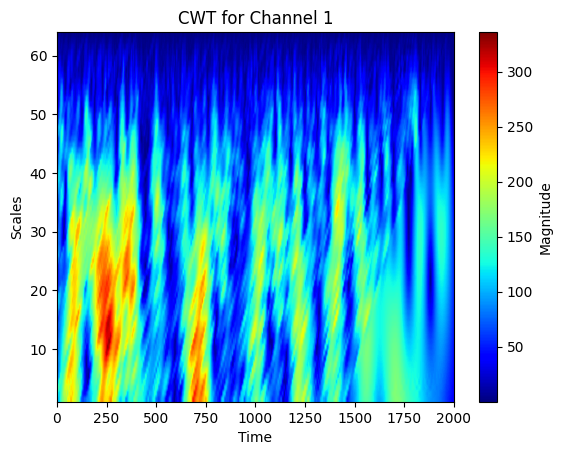

In [5]:
import pywt

# read one eeg singal from file
eeg_file = os.path.join(dataset_dir, f"filtered_eeg_windows_60Hz/338.csv")
eeg_df = pd.read_csv(eeg_file)

# Stampa le prime 5 righe del dataframe
print(eeg_df.head())

# Definisci una funzione per applicare la trasformata continua di wavelet (CWT)
def apply_cwt_to_eeg(eeg_data, wavelet='cmor', n_scales=64):
    cwt_results = []
    for channel in eeg_data.columns:
        signal = eeg_data[channel].values  # Ottieni il segnale da un canale
        scales = np.arange(1, n_scales + 1)  # Definisci le scale per la CWT
        cwt_matrix, _ = pywt.cwt(signal, scales=scales, wavelet=wavelet)
        cwt_results.append(np.abs(cwt_matrix))  # Salva il modulo della CWT
    return np.array(cwt_results)

# Applica la trasformata CWT al segnale EEG (per tutti i canali)
cwt_results = apply_cwt_to_eeg(eeg_df)

# Stampa la forma del risultato
print("Shape of CWT results:", cwt_results.shape)

# Visualizza la CWT per un canale (esempio: il primo canale)
channel_index = 0
plt.imshow(cwt_results[channel_index], aspect='auto', cmap='jet', extent=[0, eeg_df.shape[0], 1, 64])
plt.colorbar(label='Magnitude')
plt.title(f'CWT for Channel {channel_index + 1}')
plt.xlabel('Time')
plt.ylabel('Scales')
plt.show()

In [23]:
import numpy as np
import pandas as pd
import pywt
import os

# Parametri CWT
wavelet = 'cmor'
scales = np.arange(1, 128)  # Scales scelte

# Funzione per applicare la CWT e salvare i risultati come file .npy
def preprocess_eeg_cwt(file_path, output_dir):
    # Leggi il file CSV
    eeg_data = pd.read_csv(file_path)
    eeg_data = eeg_data.values  # Converti in array NumPy
    
    # Lista per salvare i coefficienti CWT di tutti i canali
    cwt_coefficients = []
    
    for channel_data in eeg_data.T:  # Itera sui canali (colonne)
        # Applica la CWT a ciascun canale
        coeffs, _ = pywt.cwt(channel_data, scales, wavelet)
        cwt_coefficients.append(np.abs(coeffs))  # Salva l'ampiezza
    
    # Converti la lista in un array NumPy 3D (canali x scale x time)
    cwt_coefficients = np.array(cwt_coefficients)
    
    # Salva l'array come file .npy
    file_name = os.path.basename(file_path).replace('.csv', '.npy')
    output_path = os.path.join(output_dir, file_name)
    np.save(output_path, cwt_coefficients)
    # print(f'Salvato: {output_path}')

# Esempio di utilizzo
csv_file = os.path.join(dataset_dir, f"filtered_eeg_windows_60Hz/338.csv")
output_directory = os.path.join(dataset_dir, f"cwt")
os.makedirs(output_directory, exist_ok=True)  # Crea la directory se non esiste
preprocess_eeg_cwt(csv_file, output_directory)

c:\Users\marti\Documents\GitHub\HMS-kaggle-competition\env\lib\site-packages\pywt\_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should takethe form cmorB-C where B and C are floats representing the bandwidth frequency and center frequency, respectively (example: cmor1.5-1.0).
  wavelet = DiscreteContinuousWavelet(wavelet)


In [24]:
# import numpy as np
# import pandas as pd
# import pywt
# import os

# # Parametri CWT
# wavelet = 'cmor1.5-1.0'  # Specifica della wavelet con parametri
# scales = np.arange(1, 128)  # Scales scelte

# # Funzione per applicare la CWT e salvare i risultati come file .npy
# def preprocess_eeg_cwt(file_path, output_dir):
#     # Leggi il file CSV
#     eeg_data = pd.read_csv(file_path)
#     eeg_data = eeg_data.values  # Converti in array NumPy
    
#     # Lista per salvare i coefficienti CWT di tutti i canali
#     cwt_coefficients = []
    
#     for channel_data in eeg_data.T:  # Itera sui canali (colonne)
#         # Applica la CWT a ciascun canale
#         coeffs, _ = pywt.cwt(channel_data, scales, wavelet)
#         cwt_coefficients.append(np.abs(coeffs))  # Salva l'ampiezza
    
#     # Converti la lista in un array NumPy 3D (canali x scale x time)
#     cwt_coefficients = np.array(cwt_coefficients)
    
#     # Salva l'array come file .npy
#     file_name = os.path.basename(file_path).replace('.csv', '.npy')
#     output_path = os.path.join(output_dir, file_name)
#     np.save(output_path, cwt_coefficients)

# # Esempio di utilizzo
# csv_file = os.path.join(dataset_dir, "filtered_eeg_windows_60Hz/338.csv")
# output_directory = os.path.join(dataset_dir, "cwt")
# os.makedirs(output_directory, exist_ok=True)  # Crea la directory se non esiste
# preprocess_eeg_cwt(csv_file, output_directory)


File ../dataset\cwt\338.npy generato correttamente.
Dimensioni del file CWT: (20, 127, 2000)


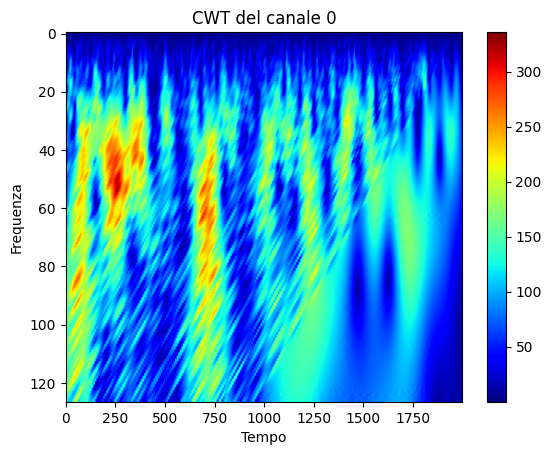

In [25]:
file_path = os.path.join(output_directory, '338.npy')
if os.path.exists(file_path):
    print(f'File {file_path} generato correttamente.')
else:
    print(f'Errore: File {file_path} non trovato.')

import numpy as np
import matplotlib.pyplot as plt

# Carica il file .npy
cwt_data = np.load(file_path)

# Stampa le dimensioni del file per verificare
print(f'Dimensioni del file CWT: {cwt_data.shape}')

# Visualizza uno dei canali per verificare (ad esempio il canale 0)
plt.imshow(cwt_data[0], aspect='auto', cmap='jet')
plt.colorbar()
plt.title('CWT del canale 0')
plt.xlabel('Tempo')
plt.ylabel('Frequenza')
plt.show()


In [28]:
import glob
import os
from tqdm import tqdm  

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Preprocessa tutti i file CSV in una cartella
input_directory = os.path.join(dataset_dir, "filtered_eeg_windows_60Hz")
output_directory = os.path.join(dataset_dir, "cwt")

# Ottieni la lista dei file CSV
csv_files = glob.glob(os.path.join(input_directory, "*.csv"))
os.makedirs(output_directory, exist_ok=True)

for file in tqdm(csv_files, desc="Elaborazione CWT dei file EEG", unit="file"):
    preprocess_eeg_cwt(file, output_directory)


Elaborazione CWT dei file EEG:   2%|▏         | 2319/106073 [1:53:28<84:37:01,  2.94s/file] 


OSError: 5080000 requested and 0 written